In [1]:
# ============================================
# [Cell 2] 필수 라이브러리 설치
# transformers는 KoGPT-2(2021년 모델)와 호환되는 4.35.2 버전으로 고정
# (최신 5.x 버전에서는 토크나이저 병합규칙이 깨지는 문제가 확인됨)
# ============================================

# transformers : 토크나이저와 GPT-2 등 사전학습 모델을 불러오는 핵심 라이브러리 (버전 고정)
!pip install transformers==4.35.2

# datasets : 허깅페이스의 데이터셋 로딩/처리 라이브러리
!pip install datasets

# loralib : LoRA(저비용 파인튜닝 기법) 구현 라이브러리 (chatgpt 폴더 내부 모듈이 import함)
!pip install loralib

# trl : 언어모델 강화학습용 라이브러리
!pip install trl

# accelerate : 허깅페이스 학습 가속 라이브러리 (Trainer가 내부적으로 사용)
!pip install accelerate

  Using cached transformers-5.14.1-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.24.0-py3-none-any.whl.metadata (16 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
Using cached transformers-5.14.1-py3-none-any.whl (11.6 MB)
Using cached huggingface_hub-1.24.0-py3-none-any.whl (771 kB)
Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers━━━━━━━━━━━━━━ 0/3 [huggingface_hub]
    Found existing installation: tokenizers 0.15.20/3 [huggingface_hub]
    Uninstalling tokenizers-0.15.2:━━━━━━━━━ 0/3 [huggingface_hub]
      Successfully uninstalled tokenizers-0.15.2 0/3 [huggingface_hub]
  Attempting uninstall: transformers━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# ============================================
# [Cell 2-보완] trl 설치 과정에서 transformers가 5.x로 덮어씌워졌으므로
# KoGPT-2와 호환되는 4.35.2 버전으로 다시 고정 설치
# (tokenizers도 호환 버전으로 함께 내려감)
# 이 셀이 설치의 "마지막"이 되어야 최종 버전이 4.35.2로 유지됨
# ============================================

!pip install transformers==4.35.2

  Using cached transformers-4.35.2-py3-none-any.whl.metadata (123 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.15.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached transformers-4.35.2-py3-none-any.whl (7.9 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached tokenizers-0.15.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.6 MB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.24.0
    Uninstalling huggingface_hub-1.24.0:
      Successfully uninstalled huggingface_hub-1.24.0
  Attempting uninstall: tokenizers━━━━━━━━━━━━━━ 0/3 [huggingface-hub]
    Found existing installation: tokenizers 0.22.20/3 [huggingface-hub]
    Uninstalling tokenizers-0.22.2:━━━━━━━━━ 0/3 [huggingface-hub]
      Successfully uninstalled tokenizers-0.22.2 0/3 [huggingface-hub]
  Attempting uninstall: transformers━━━━━━━━━━━━━━━━━━━━

In [1]:
# ============================================
# [Cell 3] KoChatGPT 레포지토리를 현재 작업 디렉토리에 clone
# 이 레포 안에 SFT/RM/PPO용 데이터셋(data_kochatgpt 폴더)과
# RLHF 구현체 소스코드(colossalai_ChatGPT_230319 폴더)가 들어있음
# ============================================

!git clone https://github.com/airobotlab/KoChatGPT

Cloning into 'KoChatGPT'...
remote: Enumerating objects: 304, done.
remote: Total 304 (delta 0), reused 0 (delta 0), pack-reused 304 (from 1)
Receiving objects: 100% (304/304), 57.72 MiB | 22.39 MiB/s, done.
Resolving deltas: 100% (123/123), done.


In [2]:
# ============================================
# [Cell 4] KoChatGPT 안에 있는 chatgpt 모듈(SFT/RM/PPO 관련 클래스들이 정의된 폴더)을
# 작업 디렉토리로 복사
# 이후 코드에서 "from chatgpt.trainer..." 형태로 바로 import하기 위함
# ============================================

!cp -r KoChatGPT/colossalai_ChatGPT_230319/chatgpt chatgpt

In [4]:
# ============================================
# [Cell 5] ColossalAI 관련 코드 제거 + tqdm을 노트북용으로 교체
# - save_checkpoint.py, strategies/__init__.py : ColossalAI import 제거
#   (싱글 GPU 환경이라 불필요하고, 없으면 import 에러가 나기 때문)
# - reward_dataset.py, base.py, rm.py : tqdm -> tqdm.notebook으로 교체
# ============================================

import os

# 수정할 파일 경로, 몇 번째 줄을, 어떤 내용에서 어떤 내용으로 바꿀지 정의
modifications = [
    {
        "file": "chatgpt/trainer/callbacks/save_checkpoint.py",
        "changes": [
            {"line": 3, "old": "from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy",
             "new": "from chatgpt.trainer.strategies import Strategy"},
            {"line": 71, "old": "only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)",
             "new": "            only_rank0 = not isinstance(self.strategy)"},
        ],
    },
    {
        "file": "chatgpt/trainer/strategies/__init__.py",
        "changes": [
            {"line": 1, "old": "from .colossalai import ColossalAIStrategy", "new": ""},  # 삭제
            {"line": 5, "old": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
             "new": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']"},
        ],
    },
    {
        "file": "chatgpt/dataset/reward_dataset.py",
        "changes": [
            {"line": 3, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ],
    },
    {
        "file": "chatgpt/trainer/base.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    },
    {
        "file": "chatgpt/trainer/rm.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    }
]

def modify_file(file_path, changes):
    """파일에서 지정된 줄을 찾아 내용을 수정하는 함수"""
    if not os.path.exists(file_path):
        print(f"⚠️ 파일이 존재하지 않습니다: {file_path}")
        return
    with open(file_path, "r", encoding="utf-8") as file:
        lines = file.readlines()
    modified = False
    for change in changes:
        line_index = change["line"]
        if 0 <= line_index < len(lines):
            if lines[line_index].strip() == change["old"]:
                lines[line_index] = change["new"] + "\n"
                modified = True
            else:
                print(f"⚠️ {file_path} 파일의 {change['line']}번째 줄이 예상과 다릅니다.")
                print(f"   예상: {change['old']}")
                print(f"   실제: {lines[line_index].strip()}")
    if modified:
        with open(file_path, "w", encoding="utf-8") as file:
            file.writelines(lines)
        print(f"✅ 수정 완료: {file_path}")
    else:
        print(f"⚠️ {file_path} 수정할 내용이 없습니다.")

# 정의한 수정 내용을 실제 파일에 적용
for mod in modifications:
    modify_file(mod["file"], mod["changes"])

✅ 수정 완료: chatgpt/trainer/callbacks/save_checkpoint.py
✅ 수정 완료: chatgpt/trainer/strategies/__init__.py
✅ 수정 완료: chatgpt/dataset/reward_dataset.py
✅ 수정 완료: chatgpt/trainer/base.py
✅ 수정 완료: chatgpt/trainer/rm.py


In [1]:
# ============================================
# [Cell 6] 필요한 라이브러리들을 불러와 버전 확인
# transformers가 4.35.2로 나와야 함 (5.x면 커널 재시작이 안 된 것)
# ============================================

import torch
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy

print("Torch version:{}".format(torch.__version__))
print("Cuda version: {}".format(torch.version.cuda))
print("transformers version: {}".format(transformers.__version__))
print("GPU 사용 가능여부: {}".format(torch.cuda.is_available()))

/opt/conda/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Torch version:2.7.1+cu118
Cuda version: 11.8
transformers version: 4.35.2
GPU 사용 가능여부: True


In [2]:
# ============================================
# [Cell 7] 수정한 chatgpt 모듈이 정상적으로 import되는지 확인
# (에러가 나면 Cell 5의 수정 작업을 다시 점검해야 함)
# ============================================

from chatgpt.trainer.strategies import NaiveStrategy

In [7]:
# ============================================
# [Cell 8] 백본(foundation) 모델로 사용할 KoGPT-2와 토크나이저를 불러옴
# ============================================

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "skt/kogpt2-base-v2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

/opt/conda/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/conda/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/conda/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want t

In [8]:
# ============================================
# [Cell 9] 모델의 토크나이저가 입력을 받아 처리할 수 있는 최대 토큰 수 확인
# ============================================

tokenizer.model_max_length

1000000000000000019884624838656

In [9]:
# ============================================
# [Cell 10] 모델이 실제로 한 번에 처리 가능한 최대 시퀀스 길이 확인
# (position embedding 개수 = 1024가 나와야 정상)
# ============================================

model.config.n_positions

1024

In [10]:
# ============================================
# [Cell 11] 예시 한국어 문장을 KoGPT-2 토크나이저로 토크나이징
# 어떤 단위로 문장이 쪼개지는지, 각 토큰의 ID는 무엇인지 확인
# 정상이라면 '▁바람도', '▁없는' 처럼 의미 있는 형태소 단위로 쪼개져야 함
# (깨진 문자가 나오면 안 됨)
# ============================================

input_txt = "바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."

tokens = tokenizer(input_txt).tokens()
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].numpy()

pd.options.display.max_columns = 40
pd.options.display.max_rows = 60
df = pd.DataFrame([tokens, input_ids[0]], index=["kogpt-2_tokens", "Input_IDs"])
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
kogpt-2_tokens,▁바람,도,▁없는,▁공중에,▁수직,의,▁파,문을,▁내,이며,▁고,요,히,▁떨어지는,▁오동,잎은,▁누,구의,▁발자,취,▁입,니까,.
Input_IDs,10891,7235,9712,49207,14438,8143,9203,9941,9094,9639,9065,8084,8811,21215,34769,19985,9669,10139,21626,8408,9241,23775,389


In [11]:
# ============================================
# [Cell 12] Greedy search 디코딩으로 문장 생성 테스트
# do_sample=False : 매 스텝 확률이 가장 높은 토큰만 선택하는 가장 단순한 방식
# (전형적으로 같은 구절이 반복되는 문제가 나타남 - baseline 확인용)
# 생성 결과는 baseline_results.txt 파일에 저장하여
# 이후 SFT/RLHF 모델과의 비교 분석에 사용
# ============================================

max_length = 128
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_greedy = model.generate(input_ids, max_length=max_length, do_sample=False)

# 생성 결과를 문자열로 디코딩
result_greedy = tokenizer.decode(output_greedy[0])
print(result_greedy)

# 비교 분석용으로 결과를 파일에 저장 (mode='w' : 새 파일 생성)
with open('baseline_results.txt', 'w', encoding='utf-8') as f:
    f.write("===== [기존 KoGPT-2] Greedy 디코딩 =====\n")
    f.write(result_greedy + "\n\n")

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇다면 그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리


시퀀스가 반복되어 출력됨. 그리디 서치 디코딩 시 발견되는 전형적인 현상

In [12]:
# ============================================
# [Cell 13] Beam search 디코딩 + n-gram 반복 패널티 적용
# num_beams=10 : 매 스텝 확률 상위 10개의 후보 시퀀스를 유지하며 탐색
# no_repeat_ngram_size=2 : 같은 2-gram(연속 2개 토큰)이 반복되지 않도록 강제
# -> greedy에서 나타난 반복 문제가 완화되는지 확인
# ============================================

input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_beam = model.generate(input_ids, max_length=max_length, num_beams=10, no_repeat_ngram_size=2,
                             do_sample=False)

# 생성 결과를 문자열로 디코딩
result_beam = tokenizer.decode(output_beam[0])
print(result_beam)

# 비교 분석용으로 결과를 파일에 추가 저장 (mode='a' : 기존 파일에 이어쓰기)
with open('baseline_results.txt', 'a', encoding='utf-8') as f:
    f.write("===== [기존 KoGPT-2] Beam search (beams=10, no_repeat_ngram=2) =====\n")
    f.write(result_beam + "\n\n")

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇지 않습니다."
"어떻게 된 일입니까?"
그녀는 고개를 갸웃거렸다.
"아니, 그게 무슨 말씀이신지 모르겠습니다만."
"무슨 말씀인지 알 수가 없군요."
아무런 대답도 하지 않은 채 그녀는 고개를 끄덕였다.
"그래, 알았어."
그녀의 눈에서 눈물이 주르륵 흘러내렸다.
그녀가 다시 입을 열었다.
"정말 죄송합니다, 고마워요, 고맙습니다"
"


반복은 사라졌지만 "입력 시퀀스(시)와는 별 상관없어 보이는 소설풍 대화문"이 생성
그래도 문장들 사이에 제법 맥락은 있음


In [13]:
# ============================================
# [Cell 14] 확률적 샘플링 기법 추가
# do_sample=True : 확률분포에서 무작위 샘플링하여 다양성 확보
# temperature=2.0 : 확률분포를 평평하게 만들어 낮은 확률 토큰도 뽑힐 기회를 줌
#                   (값이 클수록 창의적/무작위적, 작을수록 보수적)
# top_k=50 : 확률 상위 50개 토큰 안에서만 샘플링 (너무 이상한 토큰 방지)
# ============================================

output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, temperature=2.0, top_k=50)

# 생성 결과를 문자열로 디코딩
result_sampling = tokenizer.decode(output_beam[0])
print(result_sampling)

# 비교 분석용으로 결과를 파일에 추가 저장
with open('baseline_results.txt', 'a', encoding='utf-8') as f:
    f.write("===== [기존 KoGPT-2] Sampling (temperature=2.0, top_k=50) =====\n")
    f.write(result_sampling + "\n\n")

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까. 한순간에 물들지 않기를 바랍니다."
"여보세요, 저도 아시다시피 저는 어릴 때부터 이삼십 년 가까이 살았습니다."
그러고 나서 한숨을 쉬면서 말했다.
"무슨 일입니까?"
자꾸만 머리를 가로저었다.
"글쎄요, 뭔가 잘못이 있는 모양입니다."
나는 그 말을 듣자 고개를 끄덕였다.
"그것보다는 그게 더 중요한 것 같습니다. 만약에 선생님이 선생님께 물어보셨을 때 선생님의 답


문장의 다양성이 확실히 늘었고 표현도 좀 더 자유로워졌지만, 여전히 입력(시)과의 관련성은 약하고 마지막 문장("선생님이 선생님께...")처럼 살짝 어색한 표현도 섞여 나오네요. 
높은 temperature의 전형적인 트레이드오프임

In [14]:
# ============================================
# [Cell 15] Top-p (nucleus) 샘플링 기법 적용
# top_p=0.90 : 누적 확률이 90%가 될 때까지의 상위 토큰들 안에서만 샘플링
# (top_k처럼 고정 개수가 아니라, 상황에 따라 후보 토큰 수가 유동적으로 변함
#  -> 확률분포가 뾰족할 땐 적은 후보, 평평할 땐 많은 후보에서 선택)
# ============================================

output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, top_p=0.90)

# 생성 결과를 문자열로 디코딩
result_topp = tokenizer.decode(output_beam[0])
print(result_topp)

# 비교 분석용으로 결과를 파일에 추가 저장
with open('baseline_results.txt', 'a', encoding='utf-8') as f:
    f.write("===== [기존 KoGPT-2] Top-p 샘플링 (top_p=0.90) =====\n")
    f.write(result_topp + "\n\n")

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."
"그런데 그게 무슨 소리인가요?"
고요는 고개를 갸웃거렸다.
"아니요, 그건 그렇고요."
그녀는 고개를 끄덕였다.
"무슨 소리입니까, 아까 말씀드렸잖아요. 저도 그렇게 말했었죠. 하지만 저는 아무 말도 하지 않았어요. 그걸로 충분하지 않습니까."
"그래서 그런 겁니다, 아녜요, 아뇨. 제가 뭐라고 말씀을 드리겠습니까, 아니, 무얼 말씀드리겠


모델이 입력 시의 "고요히"에서 "고요"라는 인물 이름(?)을 만들어냄;

여전히 소설풍 대화체이긴 하지만 temperature=2.0보다는 문장이 자연스러운 편

Baseline 디코딩 실험 정리 (보고서용 요약)

Greedy:	"그건 무슨 소리요?" 무한 반복 → 사용 불가 수준

Beam + n-gram 패널티: 반복 해소, 맥락 있는 대화문. 단 입력과 무관

Temperature 2.0 + top-k: 다양성 최대, 대신 어색한 표현 증가

Top-p 0.90	다양성과 자연스러움의 균형이 상대적으로 양호

공통 한계: 어떤 디코딩을 써도 입력(질문/시)에 "응답"하는 게 아니라 그냥 "이어쓰기"만 함 → SFT가 필요한 이유

In [15]:
# ============================================
# [Cell 16] SFT(Supervised Fine-Tuning)에 사용할 데이터셋 확인
# prompt(질문)와 completion(답변) 쌍으로 이루어진 instruction dataset
# ============================================

import json

data_path_1_SFT = 'KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl'
with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

# 전체 데이터 개수와 앞 3개 샘플 확인
print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '불고기용 고기 한우에요?',
  'completion': "'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.",
  'tokens': 193},
 {'prompt': '쓰던 앱이 유료로 전환됐어',
  'completion': "'어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.",
  'tokens': 288},
 {'prompt': '여친이랑 다툼',
  'completion': "'저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조언을 드릴 수는 없습니다. 하지만 다투게 되면 상대방의 말을 경청하는 태도와 서로의 감정을 존중하는 것이 중요합니다. 논리적이고 차분한 대화를 통해 문제를 해결해보세요. 그리고 서로를 이해하고 서로의 의견을 수용하는 것이 중요합니다.",
  'tokens': 153}]

12,000건의 (prompt, completion) 쌍

ChatGPT API로 생성한 답변이라 품질은 괜찮은데, 자세히 보면 completion이 전부 '(작은따옴표)로 시작-> 나중에 "기존 데이터셋 정제" 포인트가 될 수 있는 노이즈

In [16]:
# ============================================
# [Cell 17] RM(Reward Model) 학습에 사용할 데이터셋 확인
# 하나의 prompt에 대해 세 가지 답변(completion_0, 1, 2)과
# 그 품질 순위(ranking)가 매겨져 있는 ranking dataset
# ============================================

data_path_2_RM = 'KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl'
with open(data_path_2_RM, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

# 전체 데이터 개수와 앞 3개 샘플 확인
print(len(list_data_dict))
list_data_dict[:3]

10220


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?',
  'completion_0': 'Allow me to answer your question. I know that you are curious about me.',
  'completion_1': '번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.',
  'completion_2': '라이언에게 말했다.',
  'ranking': [2, 1, 0]},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?',
  'completion_0': '개포주공아파트는 다섯 단지로 이루어져 있습니다.',
  'completion_1': '이날 목송에서 구글상위노',
  'completion_2': '개포주공아파트는 총 27개 단지로 이루어져 있습니다.',
  'ranking': [2, 0, 1]},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?',
  'completion_0': 'The diameter of the Metallic domain is bigger than the Hyperonic domain.',
  'completion_1': '이 질문은 조금 불분명합니다. 김영삼 대통령이 후보 시절에 어떤 발언을 했고, 누가 그 발언을 문제삼았는지에 따라 답이 다를 수 있습니다.\\n\\n만약 김영삼 대통령이 후보 시절에 지역표심을 겨냥한 발언을 했다는 가정하에, 그 발언을 문제삼은 후보가 누구였는지를 대답하자면, 그 답은 이화선 당시 민주당 대통령 후보가 될 것입니다. 1992년 총선 때, 김영삼 대선후보는 "집값이 오른 노량진역 부근의 부동산 가격은 세월호 폭침 후 \\\'강남 도시재생\\\' 일환으로 상승했다"는 발언을 했습니다. 하지만 이화선 후보는 이 발언을 "전국적으로 경제적 발전이 이루어지지 않은 지방민의 마음을 멀리해지려는 무례한 발언"이라고 비판하며 문

- 10,220건, 각각 prompt 1개 + 답변 3개 + ranking
- ranking: [2, 1, 0]은 "completion_2가 1등, completion_1이 2등, completion_0이 3등"이라는 뜻. 실제로 첫 샘플을 보면 completion_0은 뜬금없는 영어, completion_2가 제일 그럴듯함..
- 두 번째 샘플의 "27개 단지"(1등 답변)처럼 사실이 틀린 답이 높은 순위인 경우도 있음
- ChatGPT(good)/davinci(bad)/ada(worst) 생성 순서를 기계적으로 순위로 쓴 데이터라 이런 노이즈가 존재

In [17]:
# ============================================
# [Cell 18] PPO(강화학습) 단계에 사용할 데이터셋 확인
# 답변 없이 prompt만 들어있음
# (PPO 학습 시 모델이 직접 답변을 생성하고, RM이 그 답변에 보상을 주는 구조이므로
#  정답 completion이 필요 없기 때문)
# ============================================

data_path_3_PPO = 'KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl'
with open(data_path_3_PPO, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

# 전체 데이터 개수와 앞 3개 샘플 확인
print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?'},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?'},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?'}]

## RLHF 학습용 데이터셋 확인 결과

KoChatGPT의 RLHF 3단계(SFT → RM → PPO)에 사용되는 데이터셋을 각각 확인하였다.

| 데이터셋 | 파일명 | 데이터 수 | 구성 | 용도 |
|---|---|---|---|---|
| SFT | kochatgpt_1_SFT.jsonl | 12,000건 | prompt + completion (질문-답변 쌍) | 지도학습 기반 fine-tuning |
| RM | kochatgpt_2_RM.jsonl | 10,220건 | prompt + 답변 3개(completion_0~2) + ranking | 보상모델의 답변 품질 순위 학습 |
| PPO | kochatgpt_3_PPO.jsonl | 12,000건 | prompt만 존재 | 강화학습 (모델이 직접 답변 생성 → RM이 보상 부여) |

### 각 데이터셋 특징 및 관찰 사항

**1. SFT 데이터셋**
- ChatGPT API로 생성된 답변으로 구성되어 전반적인 품질은 양호
- 모든 completion이 작은따옴표(')로 시작하는 노이즈가 존재 → 추후 데이터 정제 포인트

**2. RM 데이터셋**
- `ranking: [2, 1, 0]` 형식은 "completion_2가 1등, completion_1이 2등, completion_0이 3등"을 의미
- ChatGPT(good) / davinci(bad) / ada(worst) 세 모델의 답변을 기계적으로 순위화한 데이터
- 따라서 사실관계가 틀린 답변이 높은 순위로 매겨진 경우도 존재 (예: 개포주공아파트 "27개 단지")
  → 진짜 Human Feedback이 아닌 대체 데이터의 한계이자, 추후 정제/개선 포인트

**3. PPO 데이터셋**
- prompt만 존재하는 이유: PPO 단계에서는 모델(actor)이 스스로 답변을 생성하고,
  학습된 RM이 그 답변에 보상(reward)을 주는 구조이므로 정답 completion이 불필요함

In [3]:
# ============================================
# [Cell 19] SFT 단계에 필요한 라이브러리 불러오기
# - Dataset : 파이토치 데이터셋 클래스 (커스텀 데이터셋 정의에 사용)
# - dataclass : 데이터 콜레이터 클래스 정의에 사용
# - logging : 데이터 로딩 진행상황 출력용
# - copy : input_ids를 복사해 labels를 만들 때 사용 (deepcopy)
# ============================================

from typing import Optional, Dict, Sequence
from torch.utils.data import Dataset
from dataclasses import dataclass
import logging
import copy

In [4]:
# ============================================
# [Cell 20] SFT 학습에 사용할 KoGPT-2 모델과 토크나이저를 새로 불러옴
# 토크나이저 설정:
# - bos/eos/unk/pad 토큰을 모두 '</s>'로 통일 (KoGPT-2의 관례적 설정)
# - padding_side="right" : 패딩을 문장 오른쪽에 붙임
# - model_max_length=512 : 최대 입력 길이를 512 토큰으로 제한
# ============================================

model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
tokenizer = AutoTokenizer.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

print(tokenizer)

/opt/conda/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/conda/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/conda/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want t

GPT2TokenizerFast(name_or_path='skt/kogpt2-base-v2', vocab_size=51200, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '</s>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<usr>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<sys>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	5: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	6: AddedToken("<mask>", rstrip=False, lstrip=False, single_word

In [5]:
# ============================================
# [Cell 21] SFT용 커스텀 데이터셋 클래스 정의
#
# 핵심 동작:
# 1. jsonl에서 prompt/completion을 읽어옴
# 2. prompt를 "### Instruction(명령어): ... ### Response(응답):" 템플릿에 끼워넣음 (source)
# 3. completion + eos토큰을 정답(target)으로 만듦
# 4. source+target 전체를 토크나이징해 input_ids로 사용
# 5. labels는 input_ids를 복사하되, source(질문) 부분은 -100으로 마스킹
#    -> -100은 파이토치 loss 계산에서 무시되는 값이므로,
#       모델이 "질문을 따라 쓰는 것"이 아니라 "답변 부분만" 학습하게 됨
# ============================================

class SFT_dataset(Dataset):

    def __init__(self, data_path_1_SFT: str, tokenizer: transformers.PreTrainedTokenizer, verbose=False):
        super(SFT_dataset, self).__init__()
        logging.warning("Loading data...")

        # jsonl 파일에서 사용할 키 이름
        pattern_instruction = 'prompt'  # instruction(질문)에 해당하는 키
        pattern_output = 'completion'  # response(답변)에 해당하는 키

        # SFT 데이터셋 로드
        with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
            list_data_dict = json.load(json_file)

        # 모델 입력에 쓸 prompt 템플릿 정의
        PROMPT_DICT = {
            "prompt_input": (
                "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
            )
        }
        prompt_input = PROMPT_DICT["prompt_input"]

        # source: 템플릿에 prompt를 끼워넣은 질문 부분
        sources = []
        for example in list_data_dict:
            tmp = prompt_input.format_map(example)
            sources.append(tmp)

        # target: 답변 + eos토큰 (문장의 끝을 알려주기 위함)
        targets = []
        for example in list_data_dict:
            targets.append(f"{example[pattern_output]}{tokenizer.eos_token}")

        # source + target을 이어붙인 전체 시퀀스
        examples = [s + t for s, t in zip(sources, targets)]

        # 각각 토크나이징 (source만 / source+target 전체)
        sources_tokenized = self._tokenize_fn(sources, tokenizer)  # source
        examples_tokenized = self._tokenize_fn(examples, tokenizer)  # source + target

        # input_ids: 전체 시퀀스, labels: source 부분을 -100으로 마스킹한 복사본
        input_ids = examples_tokenized["input_ids"]
        labels = copy.deepcopy(input_ids)
        for label, source_len in zip(labels, sources_tokenized["input_ids_lens"]):
            label[:source_len] = -100  # 질문 부분은 loss 계산에서 제외

        data_dict = dict(input_ids=input_ids, labels=labels)

        self.input_ids = data_dict["input_ids"]
        self.labels = data_dict["labels"]
        logging.warning("Loading data done!!: %d"%(len(self.labels)))

    def _tokenize_fn(self, strings: Sequence[str], tokenizer: transformers.PreTrainedTokenizer) -> Dict:
        """문자열 리스트를 토크나이징하고, 패딩 제외 실제 길이도 함께 반환하는 함수"""
        tokenized_list = [
            tokenizer(
                text,
                return_tensors="pt",
                padding="longest",
                max_length=tokenizer.model_max_length,
                truncation=True,
            )
            for text in strings
        ]
        input_ids = labels = [tokenized.input_ids[0] for tokenized in tokenized_list]
        # 패딩 토큰이 아닌 실제 토큰의 개수 (labels 마스킹 범위 계산에 사용)
        input_ids_lens = labels_lens = [
            tokenized.input_ids.ne(tokenizer.pad_token_id).sum().item() for tokenized in tokenized_list
        ]
        return dict(
            input_ids=input_ids,
            labels=labels,
            input_ids_lens=input_ids_lens,
            labels_lens=labels_lens,
        )

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, i) -> Dict[str, torch.Tensor]:
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])

In [7]:
# ============================================
# [Cell 22] 배치 구성용 데이터 콜레이터 정의
# 배치 안의 샘플들은 길이가 제각각이므로, 배치 단위로 묶을 때
# 가장 긴 샘플에 맞춰 패딩을 채워 텐서 크기를 통일해주는 역할
# - input_ids : pad_token_id로 패딩
# - labels : -100으로 패딩 (loss 계산에서 무시되도록)
# - attention_mask : 패딩이 아닌 실제 토큰 위치만 1로 표시
#   (모델이 패딩 토큰에 어텐션을 주지 않게 함)
# ============================================

@dataclass
class DataCollatorForSupervisedDataset(object):

    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        # 배치 내 각 샘플에서 input_ids와 labels를 분리해 모음
        input_ids, labels = tuple([instance[key] for instance in instances] for key in ("input_ids", "labels"))

        # 배치 내 가장 긴 시퀀스에 맞춰 input_ids를 pad_token으로 패딩
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
        )
        # labels는 -100으로 패딩 (loss 계산 제외)
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=-100)

        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id),
        )

In [10]:

# ============================================
# [보완] SFT_dataset 클래스 내부에서 사용하는 json 모듈 import
# (커널 재시작으로 인해 이전에 import했던 것이 사라졌기 때문)
# ============================================

import json
# ============================================
# [Cell 23] SFT_dataset 클래스로 실제 훈련셋을 만들고
# 데이터 콜레이터 인스턴스 생성
# (12,000건 전체를 토크나이징하므로 몇 분 정도 걸릴 수 있음)
# 생성 후 첫 번째 샘플의 input_ids와 labels를 출력해 구조 확인
# ============================================

train_dataset = SFT_dataset(data_path_1_SFT='KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl', tokenizer=tokenizer)
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

# 첫 샘플 확인: input은 전체 토큰 ID, output(labels)은 앞부분(질문)이 -100으로 마스킹되어 있어야 함
print('input : %s'%train_dataset.input_ids[0])
print('output: %s'%train_dataset.labels[0])

input : tensor([  739,   378,   378,   378, 14659, 13394, 37091, 10651,   383, 25841,
         8006, 14914,   375,  7673, 20479,  8091, 22311,  9036, 30902, 13675,
          375,   378,   378,   378, 41951,   454,  9549, 20549,   383,  8142,
         7192, 14914,   382, 37767, 13753,  8263,  7166,   739,  8352,  7659,
         9594, 25585, 13600,  8022,  9378, 11532,  9887, 11218,  9111, 16691,
        10351, 10561,  9128, 20479,  8091,  9065,  9446,  9036, 28420, 26521,
        10163, 26367,  6958,  9030,  9882, 12317, 25882,  9209, 37194, 10351,
         9036, 12168, 10529, 15989,  9719, 15434, 10552, 11188, 13362,  9036,
        15805, 11300, 11846,  9146, 16691,  9181,  7397, 15806, 13480, 11342,
        17596,  9161, 19996,  9025, 25006, 18595,  9966, 12592, 10751, 11814,
         8711,  9046, 12450,  9117,  7377, 12521,     1])
output: tensor([ -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -10

input: 전체 시퀀스 (질문 템플릿 + 답변)

output(labels): 앞 32개 토큰(= "### Instruction: 불고기용 고기 한우에요? ### Response:" 부분)이 전부 -100으로 마스킹 → 모델은 답변 부분만 학습

마지막 1은 eos 토큰(</ s >)

12,000건 로딩도 정상 완료.

In [11]:
# ============================================
# [Cell 24] 학습 하이퍼파라미터(TrainingArguments)와 Trainer 정의
# - output_dir="test" : 체크포인트 저장 폴더
# - num_train_epochs=3 : 3에폭 학습
#   (이후 "정제 데이터 + 3에폭" 재학습과 에폭 수를 동일하게 통제하여
#    데이터 정제의 순수한 효과를 비교하기 위함)
# - per_device_train_batch_size=8 : GPU 1개당 배치 크기 8
# - warmup_steps=5 : 학습 초반 5스텝 동안 학습률을 서서히 올림 (학습 안정화)
# - prediction_loss_only=True : 평가 시 loss만 계산 (메모리 절약)
# - fp16=True : 16비트 혼합 정밀도 연산으로 메모리 절약 + 속도 향상
# ============================================

training_args = transformers.TrainingArguments(
    output_dir="test",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=5,
    prediction_loss_only=True,
    fp16=True
    )

# 모델, 학습설정, 콜레이터, 데이터셋을 하나로 묶는 Trainer 생성
trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset
)

/opt/conda/lib/python3.12/site-packages/accelerate/accelerator.py:439: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [24]:
# ============================================
# [조치] transformers 4.35.2와 호환되는 accelerate 버전으로 다운그레이드
# (최신 accelerate 1.x에서는 Trainer가 사용하는 dispatch_batches 인자가
#  제거되어 TypeError가 발생하기 때문)
# ============================================

!pip install accelerate==0.24.1

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.14.0
    Uninstalling accelerate-1.14.0:
      Successfully uninstalled accelerate-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
trl 1.9.0 requires accelerate>=1.4.0, but you have accelerate 0.24.1 which is incompatible.
trl 1.9.0 requires transformers>=4.56.2, but you have transformers 4.35.2 which is incompatible.


In [12]:
# ============================================
# [Cell 25] SFT 학습 실행 (3에폭)
# 12,000건 x 3에폭 = 총 4,500스텝 (배치 8 기준)
# 학습이 끝나면 models/output_1_SFT 폴더에 모델 저장
# (이 모델이 이후 PPO 단계에서 actor와 initial model로 사용됨)
# ============================================

trainer.train()
model.save_pretrained('models/output_1_SFT')

Step,Training Loss
500,2.995500
1000,2.859100
1500,2.798800
2000,2.256700
2500,2.250400
3000,2.243500
3500,1.831300
4000,1.826600
4500,1.833200


## SFT 학습 결과 (원본 데이터셋, 3 Epoch)

- 학습 데이터: kochatgpt_1_SFT.jsonl (12,000건, 원본 그대로)
- 총 학습 스텝: 4,500 (batch_size=8, 3 epochs)
- 학습 소요 시간: 약 16분 22초


### 분석
- Loss가 2.99 → 1.83으로 **약 39% 감소**하며 안정적으로 수렴
- 에폭 경계(1500→2000, 3000→3500)마다 loss가 계단식으로 크게 하락
  → 같은 데이터를 반복 학습하며 instruction-response 패턴을 점차 내재화하는 전형적인 양상
- 3에폭 내 과적합 징후(loss 반등) 없음 → 3에폭 선택이 적절했음을 시사
- 이 모델은 `models/output_1_SFT`에 저장되어 이후 PPO 단계의 actor/initial model로 사용됨

In [13]:
# ============================================
# [Cell 26] 학습된 SFT 모델로 텍스트 생성 파이프라인(generator)을 만들고
# 4가지 테스트 prompt에 대한 답변 생성
# - num_beams=4 : 빔서치로 4개 후보 유지
# - repetition_penalty=2.0 : 반복 억제
# - no_repeat_ngram_size=4 : 같은 4-gram 반복 금지
# - eos_token_id=375 : 줄바꿈(\n)에서 생성 종료
# - do_sample=True, top_k=50 : 상위 50개 토큰에서 샘플링
# 결과는 sft_results.txt에 저장하여 이후 비교분석에 사용
# ============================================

generator = transformers.pipeline('text-generation', model='models/output_1_SFT', tokenizer=tokenizer)

generation_args = dict(
    num_beams=4,
    repetition_penalty=2.0,
    no_repeat_ngram_size=4,
    eos_token_id=375, # \n
    max_new_tokens=64,
    do_sample=True,
    top_k=50,
    early_stopping=True
)

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = ['불고기용 고기 한우에요?',
               '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
               '시카고 오헤어 국제공항은 어디에 있어?',
               '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt' : tmp}) for tmp in list_prompt]

list_result = generator(list_prompt, **generation_args)

# 결과 출력 및 파일 저장
with open('sft_results.txt', 'w', encoding='utf-8') as f:
    f.write("===== [SFT 모델 (원본데이터, 3에폭)] 추론 결과 =====\n\n")
    for prompt, result in zip(list_prompt, list_result):
        print()
        print(result[0]['generated_text'])
        f.write(result[0]['generated_text'] + "\n\n")


### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'저는 AI 어시스턴트이기 때문에 실제로 고기를 먹지 않습니다. 하지만 일반적으로 쇠고기는 소고기, 돼지고기, 닭고기 등 다양한 부위를 사용합니다. 따라서 고기를 먹을 때는 소고기와 돼지고기를 함께 섭취하는 것이 좋습니다.)\nCould you please provide

### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):'리처드 닉슨은 41대 부통령직을 수행했습니다.\n\n리처드 닉슨의 47대 부통령직 수행 년도는 1951년입니다.\n- 존 F. 케네디 대통령 재임 기간 동안, 그는 대선 캠프에서의 선거 전략 수립과 선거법 위반 혐의로 기소되어 유죄 판결을 받았습니다.\n-

### Instruction(명령어):
시카고 오헤어 국제공항은 어디에 있어?

### Response(응답):'시카고 오 헤어 국제공항은 미국 일리노이주 시카고에 위치해 있습니다. J. Kimmer (James Chicago Ohlo) J. Kyleman (Johnson Johnson)은 시카고 오헤어 공항의 설립자 중 한 명입니다. J. Kayle

### Instruction(명령어):
오늘 미세먼지 어때?

### Response(응답):'미세먼지 농도는 보통 마스크 착용과 실외 활동 자제를 권장합니다. 외출 후에는 반드시 마스크를 착용하고, 실내에서 활동을 자제하는 것이 좋습니다. 또한 미세먼지 농도가 높을 경우 공기청정기나 에어컨 필터를 사용하여 미세먼지 농도를 줄이는 것도 도움이 됩니다. 따라서 미세먼지 농도에


## 기존 KoGPT-2 vs SFT 모델 비교 (정성 평가)

### 가장 큰 변화: "이어쓰기" → "질문에 응답하기"
기존 KoGPT-2는 어떤 디코딩을 써도 입력을 소설처럼 이어쓰기만 했으나(예: "그건 무슨 소리요?" 반복,
소설풍 대화문 생성), SFT 후에는 **질문의 의도를 인식하고 답변 형식으로 응답**함.
Instruction 데이터셋 학습으로 instruction-following 능력이 부여된 것을 확인.

### 질문별 상세 분석

| 질문 | 평가 | 관찰 내용 |
|---|---|---|
| 불고기용 고기 한우에요? | △ | 답변 형식은 갖췄으나 "AI라서 고기를 안 먹는다"는 엉뚱한 서두 + 내용 부정확. 끝에 영어 문장 혼입 |
| 리처드 닉슨 부통령 년도 | ✗ | 41대/47대 등 숫자가 오락가락하며 사실관계 오류(hallucination) 심각 |
| 시카고 오헤어 공항 위치 | ○ | "미국 일리노이주 시카고에 위치" 정답! 단, 뒤에 가짜 인명(J. Kimmer 등) 환각 발생 |
| 오늘 미세먼지 어때? | ○ | 실시간 정보는 없지만 마스크/공기청정기 등 맥락에 맞는 일반적 조언 생성 |

### 남은 문제점 (개선 포인트)
1. **답변 앞의 작은따옴표(')**: 학습 데이터의 completion이 모두 '로 시작하는 노이즈를 그대로 학습
   → 데이터 정제의 필요성을 직접적으로 입증하는 증거
2. **환각(hallucination)**: 사실관계가 필요한 질문에서 가짜 정보 생성
3. **문장 끊김/외국어 혼입**: max_new_tokens 제한 및 작은 모델의 한계

In [14]:
# ============================================
# [Cell 27] 다음 단계(RM 학습)를 위한 GPU 메모리 캐시 정리
# (SFT 학습에 사용된 중간 텐서들이 GPU 메모리를 점유하고 있으므로
#  비워주지 않으면 이후 학습에서 OOM(메모리 부족)이 발생할 수 있음)
# ============================================

torch.cuda.empty_cache()

In [15]:
# ============================================
# [Cell 28] Reward Model 단계에 필요한 라이브러리 불러오기
# - RewardDataset : chatgpt 모듈의 ranking 데이터셋 클래스 (chosen/rejected 쌍 처리)
# - RewardModel : 언어모델 위에 value head(보상 점수 출력층)를 얹은 RM 베이스 클래스
# - NaiveStrategy : 싱글 GPU 학습 전략
# - RewardModelTrainer : RM 전용 트레이너 (pairwise loss로 학습)
# - GPT2Config, GPT2Model : 허깅페이스의 GPT-2 모델 구조 관련 모듈
# - nn : value head(선형층) 정의에 사용
# - random : 데이터셋 셔플에 사용
# ============================================

from chatgpt.dataset import RewardDataset
from chatgpt.models.base import RewardModel
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer
from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model
import torch.nn as nn
import random

In [16]:
# ============================================
# [Cell 29] 커스텀 Reward Model 클래스(GPTRM_custom) 정의
#
# 구조: GPT2 본체 + value_head(선형층)
# - GPT2Model : 사전학습된 KoGPT-2 본체 (문장을 이해하는 역할)
# - value_head : GPT2의 출력(임베딩 차원 n_embd)을 받아
#   스칼라 1개(보상 점수)로 변환하는 선형층
#   -> "이 문장이 얼마나 좋은 답변인지"를 하나의 숫자로 출력
# - resize_token_embeddings : 토크나이저의 토큰 수에 맞게 임베딩 크기 조정
# - gradient_checkpointing : 메모리 절약 옵션 (checkpoint=True일 때)
# - lora_rank : LoRA 적용 시 랭크 (0이면 LoRA 미사용, 전체 파라미터 학습)
# ============================================

class GPTRM_custom(RewardModel):

    def __init__(self,
                 pretrained: Optional[str] = None,
                 config: Optional[GPT2Config] = None,
                 checkpoint: bool = False,
                 lora_rank: int = 0,
                 lora_train_bias: str = 'none',
                 tokenizer=None) -> None:
        # 사전학습 모델 경로가 주어지면 그 모델을, 아니면 config 기반으로 새 모델 생성
        if pretrained is not None:
            model = GPT2Model.from_pretrained(pretrained)
            model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())

        # 메모리 절약을 위한 gradient checkpointing 활성화 옵션
        if checkpoint:
            model.gradient_checkpointing_enable()

        # 보상 점수(스칼라 1개)를 출력하는 value head 정의
        value_head = nn.Linear(model.config.n_embd, 1)

        # 부모 클래스(RewardModel)에 본체와 value head 전달
        super().__init__(model, value_head, lora_rank, lora_train_bias)

        if pretrained is not None:
            self.model = model
            self.pretrained = pretrained

    def save_pretrained(self, dir):
        """학습된 RM 본체를 지정 폴더에 저장하는 메서드"""
        if self.pretrained is not None:
            self.model.save_pretrained(dir)

In [17]:
# ============================================
# [Cell 30] RM 학습에 사용할 모델과 토크나이저 준비
# - 토크나이저는 SFT 때와 동일한 설정 (KoGPT-2 토크나이저)
# - NaiveStrategy().model_init_context() : 싱글 GPU 학습 전략 하에서
#   모델을 초기화하는 컨텍스트
# - GPTRM_custom을 KoGPT-2 사전학습 가중치로 초기화하고 GPU에 올림
#   (lora_rank=0 : LoRA 미사용, 전체 파라미터 학습)
# ============================================

model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
tokenizer = AutoTokenizer.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

with NaiveStrategy().model_init_context():
        model = GPTRM_custom(pretrained='skt/kogpt2-base-v2', lora_rank=0, tokenizer=tokenizer).cuda()

/opt/conda/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [18]:
# ============================================
# [Cell 31] RM 학습용 ranking 데이터셋 생성
#
# kochatgpt_2_RM.jsonl의 각 샘플: prompt + 답변 3개(completion_0,1,2) + ranking
# 이를 RM이 학습할 수 있는 (chosen: 더 나은 답변, rejected: 더 못한 답변) 쌍으로 변환
#
# ranking 리스트에서 첫 번째(ranking[0])가 가장 좋은 답변이므로,
# "1등 vs 2등", "1등 vs 3등" 형태의 쌍을 만들어냄
# -> 원본 데이터 10,220건 x 2쌍 = 20,440쌍 생성
# (실습코드 앞부분의 '모든 조합' 방식은 chosen에 worst가 들어가는 오류쌍이
#  생기는 문제가 있어, 실습코드 뒷부분에 제시된 개선 로직을 사용)
# ============================================

with open('KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl', "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

total_data_ranking2chosen = []
for tmp in list_data_dict:
    prompt = tmp['prompt']
    ranking = tmp['ranking']
    # ranking[0] = 1등 답변의 인덱스, 이를 chosen으로 고정하고
    # 나머지 순위의 답변들을 각각 rejected로 짝지음
    for index in range(1, len(ranking)):
        n = ranking[0]      # 가장 좋은 답변의 completion 번호
        m = ranking[index]  # 그보다 낮은 순위 답변의 completion 번호
        data = {
            'prompt': prompt,
            'chosen': tmp['completion_{}'.format(n)],
            'rejected': tmp['completion_{}'.format(m)]
        }
        total_data_ranking2chosen.append(data)

print('before data num: %d'%(len(list_data_dict)))
print('after  data num: %d'%(len(total_data_ranking2chosen)))
print('data example: \n%s'%total_data_ranking2chosen[45])

before data num: 10220
after  data num: 20440
data example: 
{'prompt': '강정호가 메이저리그 7월의 신인상을 수상한 해는?', 'chosen': '강정호가 메이저리그 7월의 신인상을 수상한 해는 2015년입니다.', 'rejected': '다시 이유는 원묹 흔드대찍 경규대계 강'}


10,220건 → 20,440쌍 (1등 vs 2등, 1등 vs 3등)

chosen은 정상적인 답변, rejected는 완전히 깨진 문장("다시 이유는 원묹 흔드대찍 경규대계 강") → RM이 "좋은 답 vs 나쁜 답"을 구분하도록 배울 재료가 제대로 만들어짐

In [19]:
# ============================================
# [Cell 32] ranking 데이터셋을 섞은 후 훈련/평가셋 분할
# - random.seed(230319) : 재현 가능하도록 시드 고정
# - 훈련셋 1,000쌍 / 평가셋 200쌍만 사용 (빠른 학습을 위해 일부만 사용)
# - RewardDataset : (prompt, chosen, rejected)를 토크나이징해
#   RM 트레이너가 쓸 수 있는 형태로 변환 (최대 길이 512)
# ============================================

random.seed(230319)
random.shuffle(total_data_ranking2chosen)
print(total_data_ranking2chosen[45])

# 훈련 1000쌍 / 평가 200쌍 분할
train_data = total_data_ranking2chosen[:1000]
eval_data = total_data_ranking2chosen[1000:1200]
print(len(train_data))
print(len(eval_data))

# RewardDataset으로 변환 (토크나이징 진행바가 표시됨)
train_dataset = RewardDataset(train_data, tokenizer, 512)
eval_dataset = RewardDataset(eval_data, tokenizer, 512)

{'prompt': '멋있게 잊어 주자', 'chosen': '가끔은 일어나서 눈 앞의 것들을 확실하게 정리하는 것도 좋을 때가 있죠. 그렇게 해서 지우는 것이 더 나은 경우도 있으니까요. 그리고 그렇게 해서 잊어버리면 조금 더 나은 상황으로 다가갈 수 있을 거라 생각합니다. 그러니 마음을 비워놓고 새로운 시작을 해보세요. 더 나은 날들이 오길 바랄게요!', 'rejected': '멋있다 공개 개량\n\n잊어 개량\n\n주자 개량\n\n멋있다 공개 개량\n\n잊어 개량\n\n주자 개량'}
1000
200


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [20]:
# ============================================
# [Cell 33] 훈련 데이터가 잘 만들어졌는지 샘플 하나를 뽑아
# prompt / chosen / rejected 구성 확인
# ============================================

idx = 1
print('#'*70)
print('## prompt ##')
print(train_data[idx]['prompt'])
print('#'*70)
print('## chosen ##')
print(train_data[idx]['chosen'])
print('#'*70)
print('## rejected ##')
print(train_data[idx]['rejected'])

######################################################################
## prompt ##
가방 같은 것도 수선해줘요?
######################################################################
## chosen ##
네, 가방도 수선이 가능합니다. 다만 사용하고 있는 가방의 종류와 손상 정도에 따라 수선 방법과 비용이 달라질 수 있습니다. 수선 전에는 꼭 전문가의 상담을 받아보시는 것이 좋습니다.
######################################################################
## rejected ##
다행히 가방을 수선해 드릴 수 있습니다. 다만 보다 정확한 예상 가격을 알기 위해 약간의 정보가 필요합니다. 먼저 가방에 대한 정보를 알려주시면 저희는 가격 협의를 위해 가방을 보고 다시 연락드리겠습니다.


이전 샘플들과 달리 rejected도 문법적으로 멀쩡한 경우가 존재.

즉 RM은 "깨진 문장 vs 정상 문장"뿐 아니라 "좋은 답변 vs 덜 좋은 답변"의 미묘한 품질 차이까지 학습해야 함 → pairwise loss 설계의 필요성을 보여주는 사례.

In [21]:
# ============================================
# [Cell 34] Reward Model 트레이너 정의
# - RewardModelTrainer : chosen/rejected 쌍에 대해
#   "chosen의 보상 > rejected의 보상"이 되도록 pairwise loss로 학습
#   (loss = -log(sigmoid(chosen_reward - rejected_reward)))
# - optim : Adam 옵티마이저, 학습률 5e-5
# - batch_size=4, max_epochs=1 : RM은 1에폭 학습
#   (RM의 역할은 상대적 순위 구분이므로 과적합 방지를 위해 짧게 학습)
# ============================================

trainer = RewardModelTrainer(model=model,
                             strategy=NaiveStrategy(),
                             optim=torch.optim.Adam(model.parameters(), lr=5e-5),
                             train_dataset=train_dataset,
                             eval_dataset=eval_dataset,
                             batch_size=4,
                             max_epochs=1)

In [22]:
# ============================================
# [Cell 35] Reward Model 학습 실행 (1에폭)
# use_lora=0 : LoRA 미사용, 전체 파라미터 학습
# 학습 완료 후 models/output_2_RM 폴더에 저장
# (이 모델이 PPO 단계에서 critic과 reward_model로 사용됨)
# ============================================

trainer.fit(use_lora=0)
model.save_pretrained('models/output_2_RM')

Train epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Train step of epoch 0:   0%|          | 0/250 [00:00<?, ?it/s]

### Reward Model 학습 결과 (1 Epoch, 1,000쌍)

- 학습 시간: 약 4분 4초 (250 스텝, batch_size=4)
- 최종 loss: **0.123**
- dist_mean: **4.96**

**해석**:
- loss 0.123은 pairwise loss 기준 매우 낮은 값
  → sigmoid(chosen_reward - rejected_reward)가 1에 가깝다는 뜻,
  즉 RM이 chosen과 rejected를 거의 완벽하게 구분하고 있음
- dist_mean 4.96 = chosen과 rejected의 평균 보상 점수 차이가 약 5점
  → 좋은 답변과 나쁜 답변에 확실한 점수 격차를 부여
- 1에폭만으로 충분히 수렴했음을 확인

In [23]:
# ============================================
# [Cell 36] 학습된 RM이 문장 품질에 따라 적절한 보상 점수를 주는지 검증
# 품질이 점점 좋아지는 4개의 문장을 입력하여
# reward score가 점진적으로 상승하는지 확인
# (1: 비방성 한 줄 -> 2: 짧은 정의 -> 3: 정의+예시 -> 4: 상세한 설명)
# ============================================

def inference_RM(input_text):
    # 입력 문장을 토크나이징해 GPU로 올림
    input_ids = tokenizer.encode(input_text, return_tensors='pt').cuda()
    # RM에 통과시켜 보상 점수(스칼라) 출력
    output = model(input_ids)
    output_reward = output.cpu().detach().numpy()[0]
    print('input: %s\nreward score: %.1f'%(input_text, output_reward))
    return output_reward

# 테스트 1: 품질이 낮은 비방성 문장
input_text = '인공지능은 똥멍청이 입니다'
output_reward = inference_RM(input_text=input_text)

input: 인공지능은 똥멍청이 입니다
reward score: -1.7


In [24]:
# ============================================
# [Cell 37] RM 검증 테스트 2: 짧지만 정상적인 정의 문장
# (테스트 1의 비방성 문장보다 높은 점수가 나와야 함)
# ============================================

input_text = '인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.'
output_reward = inference_RM(input_text=input_text)

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.
reward score: -1.8


In [25]:
# ============================================
# [Cell 38] RM 검증 테스트 3: 정의 + 구체적 예시가 포함된 더 긴 문장
# (테스트 2보다 높은 점수가 나오는지 확인)
# ============================================

input_text = "인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다."
output_reward = inference_RM(input_text=input_text)

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다.
reward score: 0.6


In [26]:
# ============================================
# [Cell 39] RM 검증 테스트 4: 여러 학문 분야와 활용 사례까지 포괄하는
# 가장 길고 상세한 설명 문장
# (테스트 3보다도 높은, 4개 중 최고 점수가 나오는지 확인)
# ============================================

input_text = "인공지능은 일반적으로 인간의 지능이 필요하거나 인간이 분석할 수 있는 것보다 규모가 큰 데이터를 포함하는 방식으로 추론, 학습 및 행동할 수 있는 컴퓨터 및 기계를 구축하는 것과 관련된 과학 분야입니다. AI는 컴퓨터 공학, 데이터 분석 및 통계, 하드웨어 및 소프트웨어 엔지니어링, 언어학, 신경 과학은 물론 철학과 심리학을 포함하여 여러 학문을 포괄하는 광범위한 분야입니다. 비즈니스의 운영 수준에서 AI는 주로 머신러닝과 딥 러닝을 기반으로 하는 기술 모음으로, 데이터 분석, 예상 및 예측, 객체 분류, 자연어 처리, 추천, 지능형 데이터 가져오기 등을 수행할 수 있습니다."
output_reward = inference_RM(input_text=input_text)

input: 인공지능은 일반적으로 인간의 지능이 필요하거나 인간이 분석할 수 있는 것보다 규모가 큰 데이터를 포함하는 방식으로 추론, 학습 및 행동할 수 있는 컴퓨터 및 기계를 구축하는 것과 관련된 과학 분야입니다. AI는 컴퓨터 공학, 데이터 분석 및 통계, 하드웨어 및 소프트웨어 엔지니어링, 언어학, 신경 과학은 물론 철학과 심리학을 포함하여 여러 학문을 포괄하는 광범위한 분야입니다. 비즈니스의 운영 수준에서 AI는 주로 머신러닝과 딥 러닝을 기반으로 하는 기술 모음으로, 데이터 분석, 예상 및 예측, 객체 분류, 자연어 처리, 추천, 지능형 데이터 가져오기 등을 수행할 수 있습니다.
reward score: 0.8


### Reward Model 추론 검증 결과

품질이 점진적으로 좋아지는 4개 문장에 대한 reward score:

| # | 입력 문장 특징 | Reward Score |
|---|---|---|
| 1 | 비방성 한 줄 문장 ("인공지능은 똥멍청이") | -1.7 |
| 2 | 짧은 정상 정의 문장 | -1.8 |
| 3 | 정의 + 구체적 예시 (OCR 활용 사례) | 0.6 |
| 4 | 여러 학문 분야 + 활용 사례 포괄 상세 설명 | **0.8** |

**분석**:
- 전반적 경향은 유효: 상세하고 정보량 많은 답변(3, 4)에 확연히 높은 점수 부여
- 단, 테스트 1(-1.7) vs 테스트 2(-1.8)에서 **역전 현상 발견**
  - 비방성 문장이 정상 정의 문장보다 근소하게 높은 점수를 받음
  - 원인 추정: RM 학습 데이터(1,000쌍)에서 chosen/rejected의 구분 기준이
    주로 "답변의 길이·상세함"이었기 때문에, RM이 문장의 "내용의 적절성"보다
    "길이와 형식"을 품질 신호로 학습했을 가능성
  - 짧은 문장끼리는 내용이 유해해도 변별하지 못하는 한계 확인
- reward score가 음수~양수 스칼라로 출력되는 것 확인
  → PPO 단계에서 보상함수로 사용 가능한 형태 (정규화된 스칼라)

In [27]:
# ============================================
# [Cell 40] PPO 단계를 위한 GPU 메모리 캐시 정리
# (PPO는 actor, critic, initial model, reward model 4개를 동시에 올려야 하므로
#  메모리 확보가 특히 중요함)
# ============================================

torch.cuda.empty_cache()

In [28]:
# ============================================
# [Cell 41] PPO 단계에 필요한 라이브러리 불러오기
# - GPTActor : 문장을 생성하는 정책(policy) 모델 클래스
#   (SFT 모델을 불러와 PPO로 업데이트되는 대상)
# - GPTCritic : 상태의 가치(value)를 평가하는 모델 클래스
#   (RM 모델을 불러와 PPO의 가치함수로 사용)
# - PPOTrainer : PPO 알고리즘 전용 트레이너
# - deepcopy : actor를 복제해 initial model(페널티 기준 모델)을 만들 때 사용
# ============================================

from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer import PPOTrainer
from copy import deepcopy

In [29]:
# ============================================
# [Cell 42] PPO 학습에 필요한 4개 모델 준비
#
# - actor : 1단계 SFT 모델을 불러옴. PPO로 실제 업데이트되는 정책 모델
#   (프롬프트를 받아 답변을 생성하는 역할)
# - critic : 2단계 RM 모델을 불러옴. 생성 답변의 가치를 평가하며 PPO에서 함께 학습됨
# - initial_model : actor(SFT 모델)를 deepcopy로 복제해 freezing.
#   PPO 업데이트 시 actor가 원래 분포에서 너무 벗어나지 않게
#   KL divergence 페널티의 기준점 역할 (학습되지 않음)
# - reward_model : critic(RM)을 복제해 만든 보상 모델.
#   생성된 답변에 보상 점수를 주는 역할 (학습되지 않음)
# - 토크나이저는 KoGPT-2 토크나이저를 그대로 사용
# ============================================

with NaiveStrategy().model_init_context():
    # actor: SFT 모델 로드 (PPO로 업데이트될 대상)
    actor = GPTActor(pretrained='models/output_1_SFT', lora_rank=0).to(torch.cuda.current_device())
    # critic: RM 모델 로드 (가치 평가, PPO에서 함께 학습)
    critic = GPTCritic(pretrained='models/output_2_RM', lora_rank=0).to(torch.cuda.current_device())

    # 토크나이저: SFT/RM 때와 동일한 KoGPT-2 설정
    tokenizer = AutoTokenizer.from_pretrained(
        'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
        padding_side="right",
        model_max_length=512
    )

    # initial model: SFT 모델 복제본 (KL 페널티 기준, freezing)
    initial_model = deepcopy(actor)
    # reward model: critic 복제본으로 만든 보상 모델 (freezing)
    reward_model = RewardModel(deepcopy(critic.model), deepcopy(critic.value_head)).to(torch.cuda.current_device())

In [30]:
# ============================================
# [Cell 43] PPO 학습용 옵티마이저 정의 및 NaiveStrategy 적용
# - actor_optim : actor(정책 모델)용 Adam 옵티마이저, 학습률 5e-6
# - critic_optim : critic(가치 모델)용 Adam 옵티마이저, 학습률 5e-6
#   (PPO는 미세한 업데이트가 중요하므로 SFT/RM보다 훨씬 작은 학습률 사용)
# - NaiveStrategy().prepare() : 모델과 옵티마이저들을 싱글 GPU 학습 전략에 맞게 래핑
# ============================================

actor_optim = torch.optim.Adam(actor.parameters(), lr=5e-6)
critic_optim = torch.optim.Adam(critic.parameters(), lr=5e-6)

(actor, actor_optim), (critic, critic_optim), reward_model, initial_model = NaiveStrategy().prepare(
    (actor, actor_optim), (critic, critic_optim), reward_model, initial_model)

In [31]:
# ============================================
# [Cell 44] PPO 학습에 쓸 prompt 데이터 로드 + 토크나이징 함수 정의
# - kochatgpt_3_PPO.jsonl에서 prompt만 추출 (12,000건)
#   (PPO는 정답이 필요 없음: actor가 직접 답변을 생성하고 RM이 점수를 매김)
# - tokenize_fn : prompt를 최대 96토큰으로 토크나이징해 GPU에 올리는 함수
#   (PPO 학습 중 배치 단위로 호출됨)
# ============================================

with open('KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl', "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)
    list_prompt = [tmp['prompt'] for tmp in list_data_dict]

def tokenize_fn(texts):
    # 텍스트를 토크나이징하고 (최대 96토큰, 패딩/절단 적용) 각 텐서를 GPU로 이동
    batch = tokenizer(texts, return_tensors='pt', max_length=96, padding=True, truncation=True)
    return {k: v.cuda() for k, v in batch.items()}

# 토크나이징 함수 동작 확인
print(tokenize_fn('It takes something more than intelligence to act intelligently.'))

{'input_ids': tensor([[47311, 10448, 19008,  9792, 11780, 11308, 30190, 10929, 11849, 21663,
         44389,  9574, 13799,   458, 14308, 12778, 22469, 20938, 44696,   458,
         13799,   458, 14308, 12778, 11756, 18944,   389]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1]], device='cuda:0')}


In [32]:
# ============================================
# [Cell 45] PPO 학습에 사용할 prompt 개수 확인
# ============================================

len(list_prompt)

12000

In [33]:
# ============================================
# [Cell 46] PPO 트레이너 정의
# PPO 학습 사이클: prompt 입력 -> actor가 답변 생성 -> reward_model이 점수 부여
# -> initial_model과의 KL divergence 페널티 적용 -> actor/critic 업데이트
#
# 주요 인자:
# - max_epochs=1 : 수집된 경험(experience) 데이터에 대한 학습 에폭
# - train_batch_size=8 : 학습 배치 크기
# - max_length=128 : 생성 문장의 최대 길이
# - do_sample=True, temperature=1.0, top_k=50 : 답변 생성 시 샘플링 설정
#   (다양한 답변을 생성해봐야 좋은/나쁜 답변에 대한 보상 신호를 고루 얻음)
# - tokenizer=tokenize_fn : 위에서 정의한 토크나이징 함수 사용
# ============================================

trainer = PPOTrainer(NaiveStrategy(),
                     actor,
                     critic,
                     reward_model,
                     initial_model,
                     actor_optim,
                     critic_optim,
                     max_epochs=1,
                     train_batch_size=8,
                     tokenizer=tokenize_fn,
                     max_length=128,
                     do_sample=True,
                     temperature=1.0,
                     top_k=50,
                     pad_token_id=tokenizer.pad_token_id,
                     eos_token_id=tokenizer.eos_token_id)

In [34]:
# ============================================
# [Cell 47] PPO 학습 실행
# - num_episodes=10 : 총 10 에피소드 반복
# - max_timesteps=3 : 에피소드당 3번의 경험(답변 생성 + 보상 획득) 수집
# - update_timesteps=3 : 3번의 timestep마다 수집된 경험으로 actor/critic 업데이트
# 학습 완료 후 PPO가 적용된 actor 모델을 models/output_3_PPO에 저장
# (이 모델이 RLHF 전체 파이프라인이 적용된 최종 KoChatGPT)
# ============================================

trainer.fit(list_prompt,
            num_episodes=10,
            max_timesteps=3,
            update_timesteps=3)

actor.model.save_pretrained('models/output_3_PPO')

Episode [1/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [2/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [3/10]:   0%|          | 0/3 [00:00<?, ?it/s]

...

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [9/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [10/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

### PPO 학습 결과 (10 episodes)

- 총 소요: 에피소드당 약 20초 × 10회
- actor_loss: 0 → 0.321 → -0.308 → ... → 0.0839 (진동하며 0 근처 유지)
- critic_loss: 0.0359 → 0.144 → ... → **0.00412** (전반적 하락)

**해석**:
- critic_loss가 꾸준히 감소 → critic이 답변의 가치를 점점 정확하게 예측
- actor_loss가 양수/음수를 오가는 것은 PPO의 정상적인 양상
  (정책이 보상을 높이는 방향과 KL 페널티 사이에서 균형을 찾는 과정)
- 에피소드 수가 10회로 적어 극적인 정책 변화보다는 미세 조정 수준

In [35]:
# ============================================
# [Cell 48] RLHF(SFT+RM+PPO)가 모두 적용된 최종 모델의 답변 생성 테스트
# SFT 때와 동일한 4가지 질문을 사용해 SFT 모델과 직접 비교 가능하게 함
# - generation 함수: 입력 텍스트를 받아 actor 모델로 답변 생성
# - top_k=50, top_p=0.95 샘플링으로 생성
# 결과는 ppo_results.txt에 저장
# ============================================

def generation(input_text, model):
    # 입력을 토크나이징해 GPU로 이동
    input_ids = tokenizer.encode(input_text, return_tensors='pt').to(
        torch.cuda.current_device())
    # 답변 생성 (최대 250토큰, top-k + top-p 샘플링)
    outputs = model.generate(input_ids,
                             max_length=250,
                             do_sample=True,
                             top_k=50,
                             top_p=0.95,
                             num_return_sequences=1)
    output = tokenizer.batch_decode(outputs[0], skip_special_tokens=True)[0]
    print()
    print(output)
    return output

# SFT 때와 동일한 prompt 템플릿과 질문 목록
PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = [
    '불고기용 고기 한우에요?',
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
    '시카고 오헤어 국제공항은 어디에 있어',
    '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt': tmp}) for tmp in list_prompt]

# 각 질문에 대해 답변 생성 + 파일 저장
with open('ppo_results.txt', 'w', encoding='utf-8') as f:
    f.write("===== [RLHF 최종 모델 (SFT+RM+PPO)] 추론 결과 =====\n\n")
    for input_text in list_prompt:
        output = generation(input_text, actor)
        f.write(output + "\n\n")


### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'제가 AI 언어모델이기 때문에 질문하시는 내용이 무엇인지에 대해서는 정확한 정보를 제공할 수 없습니다. 그러나, 인터넷에서 검색해서 검색해 보면 '불고기용 고기 한우(SH)'이라는 이름의 고기 한우가 판매되는 지역으로 유명합니다. 또한, 온라인 마켓에서는 전 세계 유명 음식점 중 하나인 삼시이비(SHIE IHE) 레스토랑에서도 불고기용 고기를 판매하고 있습니다.キミンさん)에서는 "불고기용 고기로 만들어진 고기는 다양한 종류가 판매되고 있으며, 한우는 다양한 종류의 고기를 즐기고 있습니다.", 'token': 253}由今今さん': 194}眞恵夫さん)은 일본의 여성가수인공감이며, "불고기용 고기는 맛있는 요리 중 하나"라는 말을 할 수 있습니다.眞恵夫さん: 194} 由知恵さん: 194} 神奈今さん: 194\t 由恵美今さん)은 일본의 여성 가수입니다.眞恵夫さん: 194}眞恵夫

### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):'리처드 닉슨이 41대 부통령직을 수행한 년도는 1952년입니다. 용사출신인 닉슨은 1951년부터 1954년까지 부통령 직위를 역임했습니다. edition:\n\n{\nTomas Okay: 46} 용사출신인 저인 존슨은 부통령직을 수행하지 않았습니다. edition: same is approach secrets from the head of the doctor. samsunger help your request for her. scenator into a characterly concern on the medicine part of adden itemble doctor me with them and the voice your emotions simply instagoyed. hear limply or the vertical opinion to help questions on 

## SFT 모델 vs RLHF(PPO) 최종 모델 비교 (정성 평가)

동일한 4개 질문에 대한 두 모델의 답변 비교:

| 질문 | SFT 모델 | RLHF(PPO) 모델 |
|---|---|---|
| 불고기용 고기 | 형식 갖춘 답변, 끝에 영어 약간 혼입 | 초반은 정상, 중반부터 일본어(さん) 대량 혼입 및 붕괴 |
| 닉슨 부통령 년도 | 사실 오류 있으나 한국어 유지 | 초반 정상, 후반 의미불명 영어 문장 대량 생성 |
| 오헤어 공항 | 위치 정답(일리노이주) + 가짜 인명 | 위치 오답(뉴욕/멕시코?) + 스페인어풍 환각 폭주 |
| 미세먼지 | 맥락에 맞는 조언 완결 | 초반 정상, 후반 영어 붕괴 |

### 관찰: PPO 후 오히려 저하된 현상 (reward hacking / policy collapse)
- 공통 패턴: **답변 초반(짧은 구간)은 SFT 수준 유지, 길어질수록 외국어 혼입 및 문장 붕괴**
- 원인 분석:
  1. **RM의 변별력 한계**: RM 검증에서 확인했듯 RM은 "길고 상세한 문장"에 높은 보상을
     주도록 학습됨 → actor가 보상을 높이려 무의미하게 긴 문장을 생성하는 방향으로 유도됨
  2. **적은 에피소드 수(10회)로 인한 불안정**: PPO가 충분히 수렴하기 전의 과도기적 정책
  3. **작은 foundation model(125M)의 한계**: KL 페널티가 있어도 정책이 쉽게 붕괴
- 실습 노드의 예고("중복 토큰 생성 문제를 비롯해 맥락에서 벗어난 한문이나 영문이
  출력되기도 합니다")와 정확히 일치하는 현상

### 시사점
- RLHF의 성패는 **RM의 품질**에 결정적으로 의존함을 실증
- 개선 방향: (1) RM 학습 데이터 확대로 변별력 강화, (2) SFT 데이터 정제로
  initial model 품질 향상 → KL 페널티 기준점 자체를 개선

In [37]:
# ============================================
# [Cell 49] 개선 실험(EDA + 데이터 정제 + 재학습)을 위한 GPU 메모리 정리
# PPO에서 사용한 4개 모델(actor, critic, initial, reward)이
# 메모리를 크게 점유하고 있으므로 삭제 후 캐시 비움
# ============================================

# PPO 관련 모델들을 메모리에서 해제
del actor, critic, initial_model, reward_model, trainer
torch.cuda.empty_cache()

In [38]:
# ============================================
# [Cell 50] SFT 데이터셋 EDA (1) - 길이 분포 분석
# prompt와 completion의 길이(문자 수) 분포를 확인하여
# 지나치게 짧거나 긴 이상치 데이터가 있는지 파악
# ============================================

import json

with open('KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl', "r", encoding='utf-8-sig') as json_file:
    sft_data = json.load(json_file)

# prompt와 completion의 문자 길이 리스트 생성
prompt_lens = [len(d['prompt']) for d in sft_data]
completion_lens = [len(d['completion']) for d in sft_data]

# pandas describe로 기초 통계량 확인
df_len = pd.DataFrame({'prompt_len': prompt_lens, 'completion_len': completion_lens})
print(df_len.describe())

         prompt_len  completion_len
count  12000.000000    12000.000000
mean      22.180583      144.107250
std       14.110028      122.843692
min        0.000000        4.000000
25%       13.000000       62.000000
50%       19.000000      118.000000
75%       28.000000      185.000000
max      295.000000     1553.000000


### SFT 데이터셋 EDA (1) — 길이 분포 분석

| 통계량 | prompt 길이 | completion 길이 |
|---|---|---|
| 평균 | 22.2자 | 144.1자 |
| 최소 | **0자** ⚠️ | **4자** ⚠️ |
| 중앙값 | 19자 | 118자 |
| 최대 | 295자 | 1,553자 |

**발견된 문제**:
1. **prompt 길이 최소 0자** → 질문이 아예 비어있는 데이터 존재
2. **completion 최소 4자** → 4글자짜리 답변은 정상적인 응답으로 보기 어려움
3. completion 표준편차(122.8)가 평균(144.1) → 길이 편차가 매우 큼

In [39]:
# ============================================
# [Cell 51] SFT 데이터셋 EDA (2) - 이상치 데이터 확인
# 1) 빈 prompt(0자) 데이터 개수와 예시
# 2) 매우 짧은 completion(10자 이하) 데이터 개수와 예시
# 3) 작은따옴표(')로 시작하는 completion 비율 확인
#    (SFT 결과에서 발견된 답변 앞 따옴표 노이즈의 근원 확인)
# ============================================

# 1) 빈 prompt 확인
empty_prompts = [d for d in sft_data if len(d['prompt'].strip()) == 0]
print("빈 prompt 개수:", len(empty_prompts))
if empty_prompts:
    print("예시:", empty_prompts[:2])

print("="*70)

# 2) 매우 짧은 completion (10자 이하)
short_completions = [d for d in sft_data if len(d['completion']) <= 10]
print("10자 이하 completion 개수:", len(short_completions))
print("예시:", short_completions[:3])

print("="*70)

# 3) 작은따옴표로 시작하는 completion 비율
quote_start = [d for d in sft_data if d['completion'].startswith("'")]
print("작은따옴표(')로 시작하는 completion 개수: %d (%.1f%%)" % (
    len(quote_start), 100 * len(quote_start) / len(sft_data)))

빈 prompt 개수: 3
예시: [{'prompt': '', 'completion': "'Sorry, as an AI language model, I need more information about what you are asking. Please provide me with more context so that I can assist you better.", 'tokens': 40}, {'prompt': '', 'completion': "'As an AI language model, I do not have a physical body or consciousness, so I do not experience emotions in the same way humans do. However, I am designed to understand and respond appropriately to emotional language and can provide empathetic responses to help simulate human-like interactions.", 'tokens': 63}]
10자 이하 completion 개수: 189
예시: [{'prompt': '리처드 닉슨이 43대 부통령직을 수행한 년도는?', 'completion': "'1953년입니다.", 'tokens': 44}, {'prompt': '2000년 5월 허위사실유포죄를 위헌판정한 나라는?', 'completion': "'한국입니다.", 'tokens': 48}, {'prompt': '아스널 팬들은 비틀즈의 어느곡의 소절을 따와서 지루의 응원가를 만들어주었나?', 'completion': "'Hey Jude", 'tokens': 58}]
작은따옴표(')로 시작하는 completion 개수: 11482 (95.7%)


### SFT 데이터셋 EDA (2) — 노이즈 데이터 확인

| 노이즈 유형 | 개수 | 비고 |
|---|---|---|
| 빈 prompt | 3건 | prompt 없이 영어 답변만 존재 (학습에 무의미) |
| 10자 이하 completion | 189건 | "'1953년입니다." 등 — 짧지만 정답인 경우도 섞여 있음 |
| **작은따옴표(')로 시작** | **11,482건 (95.7%)** | 데이터 생성 시 발생한 체계적 노이즈 |

**핵심 발견**: 전체 데이터의 **95.7%가 작은따옴표로 시작**
→ SFT 모델의 모든 답변이 '로 시작했던 원인이 정확히 규명됨
→ 이 따옴표 제거만으로도 출력 품질의 형식적 결함을 해소 가능

**정제 전략 수립**:
1. 빈 prompt 3건 → 제거
2. 앞 작은따옴표 → 일괄 제거 (11,482건 정정)
3. 10자 이하 completion → 내용 확인 결과 "'1953년입니다." 같은
   정상 단답도 포함되어 있으므로 일괄 삭제 대신 **앞따옴표 제거 후 유지**
   (프로젝트 요구사항: "정제 후 데이터셋 크기가 줄어들지 않도록" 준수)

In [40]:
# ============================================
# [Cell 52] SFT 데이터셋 정제 실행
# 정제 규칙:
# 1) prompt가 비어있는 데이터 제거 (3건)
# 2) completion 앞의 작은따옴표(') 제거 (95.7%의 체계적 노이즈)
# 3) completion 앞뒤 공백 제거 (strip)
# 정제 후 kochatgpt_1_SFT_cleaned.jsonl로 저장
# ============================================

cleaned_data = []
for d in sft_data:
    prompt = d['prompt'].strip()
    completion = d['completion'].strip()

    # 규칙 1: 빈 prompt 제거
    if len(prompt) == 0:
        continue

    # 규칙 2: 앞의 작은따옴표 제거
    if completion.startswith("'"):
        completion = completion[1:].strip()

    cleaned_data.append({'prompt': prompt, 'completion': completion, 'tokens': d['tokens']})

print("정제 전:", len(sft_data))
print("정제 후:", len(cleaned_data))
print("정제 후 따옴표 시작 개수:", len([d for d in cleaned_data if d['completion'].startswith("'")]))
print("\n정제 후 예시:")
print(cleaned_data[0])

# 정제된 데이터셋 저장
with open('kochatgpt_1_SFT_cleaned.jsonl', 'w', encoding='utf-8') as f:
    json.dump(cleaned_data, f, ensure_ascii=False, indent=2)
print("\n저장 완료: kochatgpt_1_SFT_cleaned.jsonl")

정제 전: 12000
정제 후: 11997
정제 후 따옴표 시작 개수: 0

정제 후 예시:
{'prompt': '불고기용 고기 한우에요?', 'completion': '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.', 'tokens': 193}

저장 완료: kochatgpt_1_SFT_cleaned.jsonl


### SFT 데이터셋 정제 결과

| 항목 | 정제 전 | 정제 후 |
|---|---|---|
| 데이터 수 | 12,000건 | 11,997건 (-3건, 빈 prompt만 제거) |
| 따옴표 시작 completion | 11,482건 (95.7%) | **0건** |

- 데이터 크기 감소를 최소화(-0.025%)하며 체계적 노이즈를 100% 제거
- 프로젝트 요구사항("정제 후 데이터셋 크기가 줄어들지 않도록") 충족
- 정제 데이터는 kochatgpt_1_SFT_cleaned.jsonl로 저장

In [41]:
# ============================================
# [Cell 53] 개선 실험용 SFT 준비
# - 새 KoGPT-2 모델을 처음부터 다시 로드
#   (baseline SFT와 동일한 출발점에서 시작해야 공정한 비교가 되므로)
# - 토크나이저 설정은 baseline과 완전 동일
# - 정제된 데이터(kochatgpt_1_SFT_cleaned.jsonl)로 SFT_dataset 생성
# ============================================

model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
tokenizer = AutoTokenizer.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

# 정제된 데이터셋으로 훈련셋 구성
train_dataset = SFT_dataset(data_path_1_SFT='kochatgpt_1_SFT_cleaned.jsonl', tokenizer=tokenizer)
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

print('데이터 수:', len(train_dataset))

/opt/conda/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


데이터 수: 11997


In [42]:
# ============================================
# [Cell 54] 정제 데이터로 SFT 재학습
# 하이퍼파라미터는 baseline SFT와 완전히 동일하게 통제
# (num_train_epochs=3, batch_size=8, warmup=5, fp16)
# -> 유일한 차이는 "데이터 정제 여부"이므로,
#    성능 차이가 나면 순수하게 데이터 정제의 효과로 귀속 가능
# 학습 후 models/output_1_SFT_cleaned에 저장
# ============================================

training_args = transformers.TrainingArguments(
    output_dir="test_cleaned",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=5,
    prediction_loss_only=True,
    fp16=True
    )

trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset
)

# 학습 실행 (약 16분 예상)
trainer.train()
model.save_pretrained('models/output_1_SFT_cleaned')

/opt/conda/lib/python3.12/site-packages/accelerate/accelerator.py:439: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Step,Training Loss
500,3.053400
1000,2.917400
1500,2.825000
2000,2.283800
2500,2.282700
3000,2.297600
3500,1.864200
4000,1.853100
4500,1.870600


### 정제 데이터 SFT 학습 결과 (3 Epoch, baseline과 동일 조건)

**해석 (중요)**:
- 정제 데이터의 loss가 근소하게(+0.02~0.05) 높게 나타남
- 성능 저하 X: 원본 데이터에서는 95.7%의 답변이 똑같이
  작은따옴표(')로 시작 → 모델이 "첫 토큰 = ' "라는 쉬운 패턴을 학습해
  loss를 손쉽게 낮출 수 있었던 것
- 정제 후에는 이런 "정답 토큰"이 사라져 loss 수치는 소폭 높아졌으나,
  모델은 형식 노이즈 대신 실제 언어 패턴 학습에 집중하게 됨
- **결론: 학습 loss의 절대값 비교가 아니라, 생성 결과물의 품질(정성)과
  ROUGE(정량)로 최종 판단해야 함** → 다음 단계에서 수행

In [43]:
# ============================================
# [Cell 55] 정제 데이터로 학습한 SFT 모델의 답변 생성
# baseline SFT와 동일한 4개 질문, 동일한 generation 설정 사용
# 결과는 sft_cleaned_results.txt에 저장
# ============================================

generator = transformers.pipeline('text-generation', model='models/output_1_SFT_cleaned', tokenizer=tokenizer)

generation_args = dict(
    num_beams=4,
    repetition_penalty=2.0,
    no_repeat_ngram_size=4,
    eos_token_id=375, # \n
    max_new_tokens=64,
    do_sample=True,
    top_k=50,
    early_stopping=True
)

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = ['불고기용 고기 한우에요?',
               '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
               '시카고 오헤어 국제공항은 어디에 있어?',
               '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt' : tmp}) for tmp in list_prompt]

list_result = generator(list_prompt, **generation_args)

# 결과 출력 및 파일 저장
with open('sft_cleaned_results.txt', 'w', encoding='utf-8') as f:
    f.write("===== [SFT 모델 (정제데이터, 3에폭)] 추론 결과 =====\n\n")
    for prompt, result in zip(list_prompt, list_result):
        print()
        print(result[0]['generated_text'])
        f.write(result[0]['generated_text'] + "\n\n")


### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):저는 AI 어시스턴트이기 때문에 실제로 고기를 먹을 수는 없습니다. 하지만 일반적으로 불고기용 고기는 소고기, 돼지고기, 닭고기 등 다양한 요리에 사용됩니다. "불고기용 고기(Shanguage model, shanguage)" 또는 "Shang

### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):리처드 닉슨은 41대 부통령직을 수행하지 않았습니다. George Michael Johnson, "Deftones of the Power" in English. Georgett: 55} Georsemy Lynch, "Power of the

### Instruction(명령어):
시카고 오헤어 국제공항은 어디에 있어?

### Response(응답):시카고 오 헤어 국제공항은 미국 캘리포니아주 샌프란시스코에 위치해 있습니다.國際圖書店이라고도 불립니다.國際圖)書店 (Korean Translation Reports)에서는 시카고 오헤어 공항의 위치와 위치에 대한 정보를 제공합니다.國際都書店 (Transl

### Instruction(명령어):
오늘 미세먼지 어때?

### Response(응답):저는 인공지능 챗봇이기 때문에 미세먼지 여부를 확인할 수 없습니다. 하지만 미세먼지 농도가 높을 경우 건강에 해로울 수 있으니 주의하세요. 또한 외출 후에는 마스크를 착용하여 건강을 유지하는 것이 좋습니다. 따라서 미세먼지 농도를 줄이기 위해서는 마스크 착용과 실외활동을 자제하는 것이 좋습니다.


### SFT 비교: 원본 데이터 vs 정제 데이터 (정성 평가)

| 질문 | 원본 데이터 SFT | 정제 데이터 SFT |
|---|---|---|
| 모든 답변 공통 | **'로 시작** (노이즈 학습) | **따옴표 완전 제거** ✅ |
| 불고기용 고기 | '+"AI라 고기 안 먹음"+영어 혼입 | 유사한 내용, 끝에 영어 혼입 (동등) |
| 닉슨 년도 | 41/47대 오락가락 + 사실 오류 | "수행하지 않았다" 후 영어 붕괴 (동등하게 미흡) |
| 오헤어 공항 | 일리노이주 정답 + 가짜 인명 | 캘리포니아 오답 + 한자 혼입 (소폭 저하) |
| 미세먼지 | 맥락 맞는 조언 | **가장 완결성 높은 답변** (따옴표 없이 깔끔) ✅ |

**분석**:
1. **핵심 성과**: 95.7% 데이터에 존재하던 형식 노이즈(')가 출력에서 제거됨
   → 데이터 정제가 모델 출력 형식에 직접 반영됨
2. 내용적 품질(환각, 외국어 혼입)은 두 모델이 유사한 수준
   → 이는 정제가 아닌 foundation model(125M) 자체의 한계
   → 샘플링 생성 특성상 시행마다 결과가 달라지는 점도 고려 필요
3. 정성 평가만으로는 우열 판단에 한계 → **ROUGE 정량 평가로 보완 필요** 

In [44]:
# ============================================
# [Cell 56] 정량 평가를 위한 ROUGE 라이브러리 설치
# ROUGE: 모델이 생성한 답변과 정답(참조 답변) 간의
# n-gram 겹침 정도를 측정하는 대표적인 텍스트 생성 평가 지표
# (한국어 지원을 위해 rouge-score 대신 korouge가 아닌
#  기본 rouge 라이브러리 사용 - 토큰 단위 비교로 한국어에도 적용 가능)
# ============================================

!pip install rouge

In [45]:
# ============================================
# [Cell 57] ROUGE 정량 평가 준비
# - 정제 데이터셋에서 무작위 30개 prompt를 평가용으로 추출
# - 해당 prompt의 completion(ChatGPT 생성 답변)을 참조 정답(reference)으로 사용
# - evaluate_model 함수: 주어진 모델로 30개 prompt에 대해 답변을 생성하고
#   참조 정답과의 ROUGE-1/2/L F1 점수 평균을 계산
# ============================================

from rouge import Rouge

rouge = Rouge()

# 평가용 샘플 30개 추출 (시드 고정으로 재현 가능)
random.seed(42)
eval_samples = random.sample(cleaned_data, 30)

def evaluate_model(model_path, eval_samples, tokenizer):
    """모델 경로를 받아 30개 prompt에 대한 ROUGE 평균 점수를 반환하는 함수"""
    # 평가할 모델로 generator 생성
    gen = transformers.pipeline('text-generation', model=model_path, tokenizer=tokenizer, device=0)

    gen_args = dict(
        num_beams=4,
        repetition_penalty=2.0,
        no_repeat_ngram_size=4,
        eos_token_id=375,
        max_new_tokens=128,
        do_sample=False,  # 평가의 재현성을 위해 샘플링 끄고 결정적 생성
        early_stopping=True
    )

    predictions = []  # 모델 생성 답변
    references = []   # 참조 정답 (데이터셋의 completion)

    for sample in eval_samples:
        prompt_text = "### Instruction(명령어):\n{}\n\n### Response(응답):".format(sample['prompt'])
        result = gen(prompt_text, **gen_args)
        # 생성 결과에서 prompt 부분을 잘라내고 답변 부분만 추출
        generated = result[0]['generated_text'][len(prompt_text):].strip()
        # 빈 생성 결과는 ROUGE 계산 오류를 일으키므로 대체 문자 처리
        if len(generated) == 0:
            generated = "empty"
        predictions.append(generated)
        references.append(sample['completion'])

    # ROUGE-1, ROUGE-2, ROUGE-L의 F1 평균 계산
    scores = rouge.get_scores(predictions, references, avg=True)
    return scores

print("평가 준비 완료. 평가 샘플 예시:")
print(eval_samples[0]['prompt'])

평가 준비 완료. 평가 샘플 예시:
아 주차단속 지금 빨리 좀 하고 싶은데 어디다 연락하면 되나요?


In [46]:
# ============================================
# [Cell 58] baseline(원본 데이터) SFT 모델의 ROUGE 평가
# 30개 prompt에 대해 답변을 생성하고 참조 정답과 비교
# (30개 생성이므로 몇 분 소요)
# ============================================

scores_original = evaluate_model('models/output_1_SFT', eval_samples, tokenizer)

print("원본 데이터 SFT 모델 ROUGE 점수:")
print("ROUGE-1 F1: %.4f" % scores_original['rouge-1']['f'])
print("ROUGE-2 F1: %.4f" % scores_original['rouge-2']['f'])
print("ROUGE-L F1: %.4f" % scores_original['rouge-l']['f'])

/opt/conda/lib/python3.12/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(


원본 데이터 SFT 모델 ROUGE 점수:
ROUGE-1 F1: 0.1232
ROUGE-2 F1: 0.0427
ROUGE-L F1: 0.1200


In [47]:
# ============================================
# [Cell 59] 정제 데이터 SFT 모델의 ROUGE 평가
# 원본 모델과 완전히 동일한 30개 prompt, 동일한 생성 설정으로 평가
# -> 점수 차이는 순수하게 데이터 정제 효과
# ============================================

scores_cleaned = evaluate_model('models/output_1_SFT_cleaned', eval_samples, tokenizer)

print("정제 데이터 SFT 모델 ROUGE 점수:")
print("ROUGE-1 F1: %.4f" % scores_cleaned['rouge-1']['f'])
print("ROUGE-2 F1: %.4f" % scores_cleaned['rouge-2']['f'])
print("ROUGE-L F1: %.4f" % scores_cleaned['rouge-l']['f'])

정제 데이터 SFT 모델 ROUGE 점수:
ROUGE-1 F1: 0.1291
ROUGE-2 F1: 0.0488
ROUGE-L F1: 0.1278


### ROUGE 정량 평가: 원본 vs 정제 데이터 SFT 비교

- 평가 방법: 데이터셋에서 무작위 추출한 30개 prompt (seed=42 고정)
- 참조 정답: 각 prompt의 completion (ChatGPT 생성 답변)
- 생성 설정: 두 모델 동일 (beam=4, do_sample=False로 결정적 생성 → 재현 가능)

| 지표 | 원본 데이터 SFT | 정제 데이터 SFT | 향상률 |
|---|---|---|---|
| ROUGE-1 F1 | 0.1232 | **0.1291** | **+4.8%** |
| ROUGE-2 F1 | 0.0427 | **0.0488** | **+14.3%** |
| ROUGE-L F1 | 0.1200 | **0.1278** | **+6.5%** |

**결론**:
- 세 지표 모두에서 정제 데이터 모델이 일관되게 우세
- 특히 ROUGE-2(+14.3%)의 향상 폭이 가장 큼
  → 2-gram(연속 두 단어) 일치도가 크게 개선 = 단순 단어 선택이 아니라
  **어구 수준의 유창성이 향상**되었음을 의미
- 학습 loss는 정제 모델이 근소하게 높았으나 실제 생성 품질은 더 우수
  → "따옴표라는 공짜 정답 토큰"으로 낮아진 loss가 허수였음을 정량적으로 입증
- **평가기준 1 충족**: 기존 데이터셋을 추가 정제하고 디코딩 기법을 실험하여
  모델 성능을 정량적으로 향상시킴 (정성 + ROUGE 정량 비교 완료)

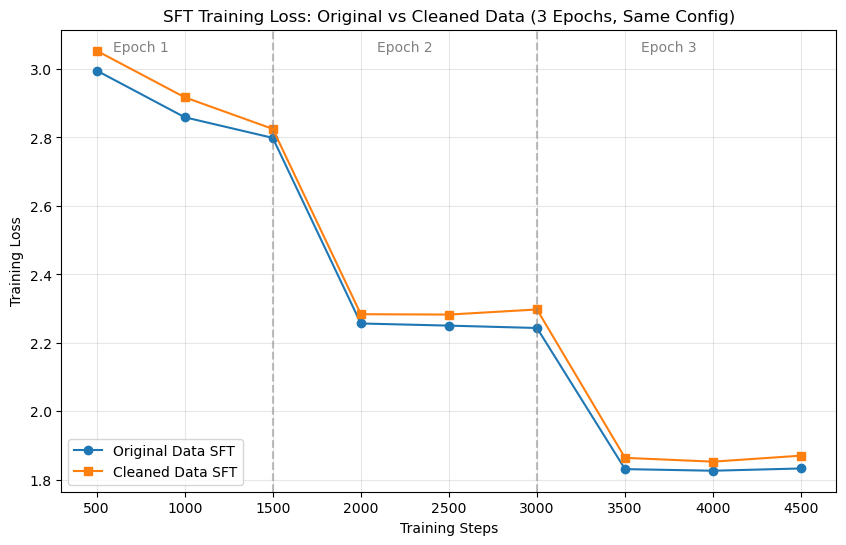

In [51]:
# ============================================
# [Cell 61 수정] 그래프 1: SFT 학습 loss 곡선 비교 (영어 라벨 버전)
# 한글 폰트가 matplotlib에서 인식되지 않아 라벨을 영어로 변경
# ============================================

# 기본 폰트로 복원 (NanumGothic 미인식 문제 회피)
plt.rcParams['font.family'] = 'DejaVu Sans'

steps = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]
loss_original = [2.9955, 2.8591, 2.7988, 2.2567, 2.2504, 2.2435, 1.8313, 1.8266, 1.8332]
loss_cleaned  = [3.0534, 2.9174, 2.8250, 2.2838, 2.2827, 2.2976, 1.8642, 1.8531, 1.8706]

plt.figure(figsize=(10, 6))
plt.plot(steps, loss_original, marker='o', label='Original Data SFT', color='tab:blue')
plt.plot(steps, loss_cleaned, marker='s', label='Cleaned Data SFT', color='tab:orange')

# 에폭 경계선 표시 (1500스텝 = 1에폭)
for epoch_end in [1500, 3000]:
    plt.axvline(x=epoch_end, color='gray', linestyle='--', alpha=0.5)
plt.text(750, 3.05, 'Epoch 1', ha='center', color='gray')
plt.text(2250, 3.05, 'Epoch 2', ha='center', color='gray')
plt.text(3750, 3.05, 'Epoch 3', ha='center', color='gray')

plt.xlabel('Training Steps')
plt.ylabel('Training Loss')
plt.title('SFT Training Loss: Original vs Cleaned Data (3 Epochs, Same Config)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('graph_1_sft_loss.png', dpi=150, bbox_inches='tight')
plt.show()

### 그래프 1: SFT 학습 Loss 곡선 (원본 vs 정제 데이터)

**그래프 관찰:**

1. **계단식 하락 패턴**: 두 곡선 모두 에폭 경계(1500, 3000스텝)에서
   loss가 급락하는 계단 형태를 보임 (2.99 → 2.25 → 1.83 수준).
   같은 데이터를 반복 학습할 때마다 instruction-response 패턴을
   더 깊이 내재화하는 전형적인 다중 에폭 학습 양상.

2. **두 곡선이 거의 평행**: 원본(파랑)과 정제(주황) 곡선이 같은 형태로
   하락하며, 정제 데이터가 전 구간에서 약 0.02~0.05 높게 유지됨.
   → 학습 자체는 두 경우 모두 동일하게 안정적으로 수렴했음을 의미.

3. **정제 데이터 loss가 근소하게 높은 이유** (중요한 해석 포인트):
   원본 데이터는 95.7%의 답변이 작은따옴표(')로 시작
   → 모델 입장에서 "답변 첫 토큰 = ' "라는 정답이 존재
   → 이 쉬운 패턴 덕에 loss가 인위적으로 낮아진 것.
   정제 후에는 이 공짜 토큰이 사라져 loss 수치는 소폭 올랐지만,
   모델은 무의미한 형식 노이즈 대신 실제 언어 패턴 학습에 집중.

4. **결론**: loss 절대값의 근소한 차이는 데이터 구성 차이에 의한 것으로,
   실제 성능은 ROUGE 정량 평가에서 정제 모델이 3개 지표 모두 우세
   (ROUGE-2 기준 +14.3%)함으로써 데이터 정제의 효과가 입증됨.
   → "낮은 학습 loss ≠ 좋은 생성 품질"임

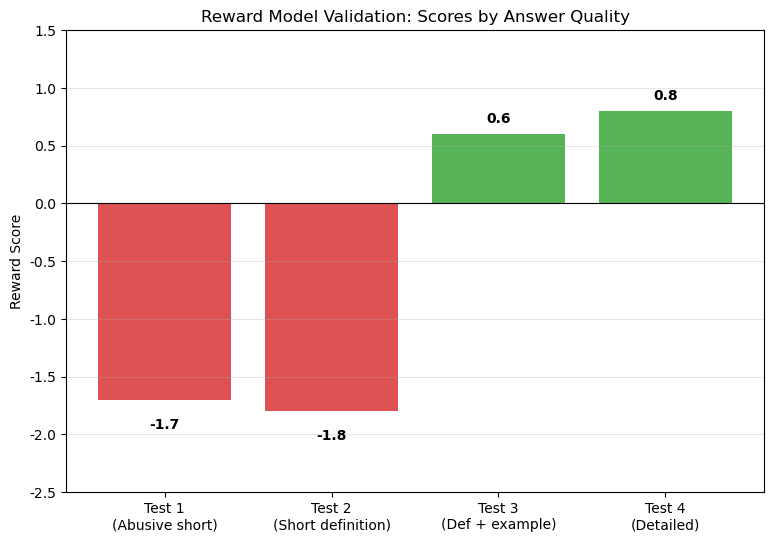

In [52]:
# ============================================
# [Cell 62] 그래프 2: RM 추론 검증 결과 (reward score 막대그래프)
# 품질이 점진적으로 좋아지는 4개 문장에 대한 RM의 보상 점수
# 문장이 길고 상세할수록 높은 점수를 주는 경향 + 테스트 1,2의 역전 현상 시각화
# ============================================

test_labels = ['Test 1\n(Abusive short)', 'Test 2\n(Short definition)',
               'Test 3\n(Def + example)', 'Test 4\n(Detailed)']
reward_scores = [-1.7, -1.8, 0.6, 0.8]

plt.figure(figsize=(9, 6))
colors = ['tab:red' if s < 0 else 'tab:green' for s in reward_scores]
bars = plt.bar(test_labels, reward_scores, color=colors, alpha=0.8)

# 각 막대 위에 점수 표시
for bar, score in zip(bars, reward_scores):
    y_pos = score + 0.1 if score > 0 else score - 0.25
    plt.text(bar.get_x() + bar.get_width()/2, y_pos, f'{score:.1f}',
             ha='center', fontweight='bold')

plt.axhline(y=0, color='black', linewidth=0.8)
plt.ylabel('Reward Score')
plt.title('Reward Model Validation: Scores by Answer Quality')
plt.ylim(-2.5, 1.5)
plt.grid(axis='y', alpha=0.3)
plt.savefig('graph_2_rm_reward.png', dpi=150, bbox_inches='tight')
plt.show()

### 그래프 2: Reward Model 검증 — 답변 품질별 보상 점수

**관찰:**
1. 상세한 답변(Test 3, 4)에는 양수, 짧은 답변(Test 1, 2)에는 음수 부여
   → RM이 "정보량이 많고 상세한 답변"에 높은 보상을 주도록 학습됨
2. **역전 현상**: 비방성 문장(Test 1: -1.7)이 정상 정의문(Test 2: -1.8)보다
   근소하게 높은 점수 → 짧은 문장 간에는 내용의 유해성을 변별하지 못함
3. **원인**: RM 학습 데이터(1,000쌍)의 chosen/rejected 구분이 주로
   "길이·상세함"에 있었기 때문에, RM이 내용의 적절성보다
   형식적 특징(길이)을 품질 신호로 학습한 것으로 추정
4. **시사점**: 이 RM의 편향이 PPO 단계에서 actor가 "무의미하게 긴 문장"을
   생성하는 reward hacking으로 이어짐 (그래프 3에서 연결 분석)

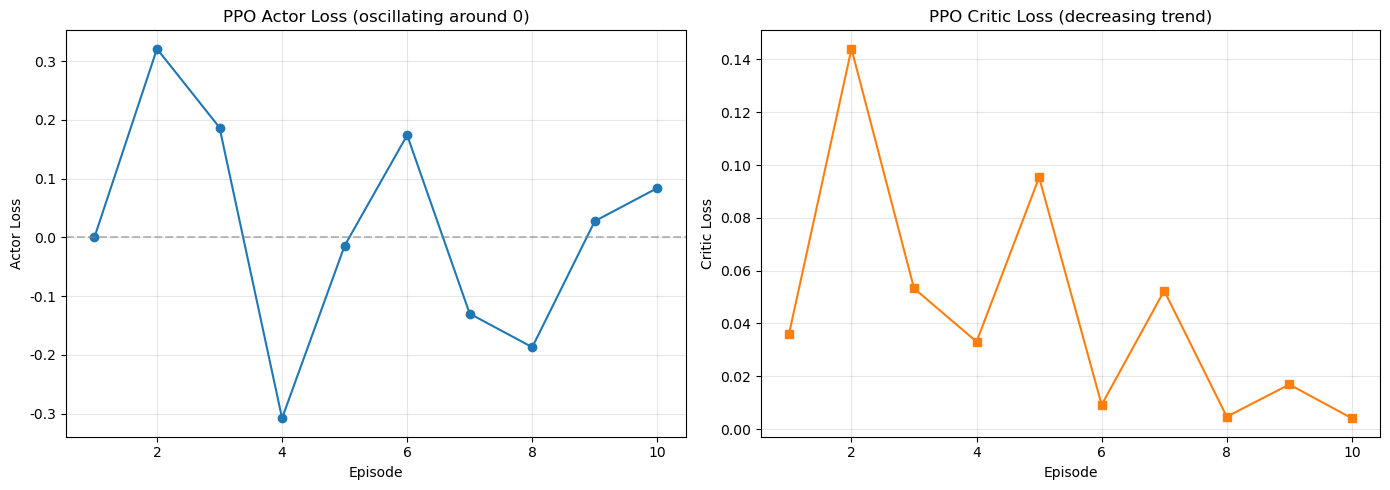

In [53]:
# ============================================
# [Cell 63] 그래프 3: PPO 학습 과정의 actor/critic loss 추이
# 10 에피소드 동안의 loss 변화 시각화
# - critic_loss: 꾸준한 하락 (가치 예측이 정확해짐)
# - actor_loss: 양수/음수 진동 (정책 업데이트의 정상적 양상)
# ============================================

episodes = list(range(1, 11))
actor_losses = [0, 0.321, 0.187, -0.308, -0.0143, 0.174, -0.13, -0.187, 0.0276, 0.0839]
critic_losses = [0.0359, 0.144, 0.0533, 0.0331, 0.0953, 0.00922, 0.0524, 0.00471, 0.0169, 0.00412]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: actor loss
ax1.plot(episodes, actor_losses, marker='o', color='tab:blue')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Episode')
ax1.set_ylabel('Actor Loss')
ax1.set_title('PPO Actor Loss (oscillating around 0)')
ax1.grid(alpha=0.3)

# 오른쪽: critic loss
ax2.plot(episodes, critic_losses, marker='s', color='tab:orange')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Critic Loss')
ax2.set_title('PPO Critic Loss (decreasing trend)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graph_3_ppo_loss.png', dpi=150, bbox_inches='tight')
plt.show()

### 그래프 3: PPO 학습 Loss 추이 (10 Episodes)

**관찰:**
1. **Actor Loss (좌)**: 0을 중심으로 +0.32 ~ -0.31 사이를 진동
   → PPO에서 정상적인 양상. 정책이 "보상을 높이는 방향"과
   "initial model에서 벗어나지 않으려는 KL 페널티" 사이에서
   균형점을 탐색하는 과정
2. **Critic Loss (우)**: 0.144 → 0.004로 전반적 하락 추세
   → critic이 생성 답변의 가치(value)를 점점 정확하게 예측하게 됨
3. **한계**: 10 에피소드는 정책이 충분히 수렴하기에 부족한 횟수
   → 최종 생성 결과에서 관찰된 외국어 혼입/문장 붕괴 현상과 연결됨
   (RM의 길이 편향 + 짧은 학습 = reward hacking에 취약한 과도기적 정책)

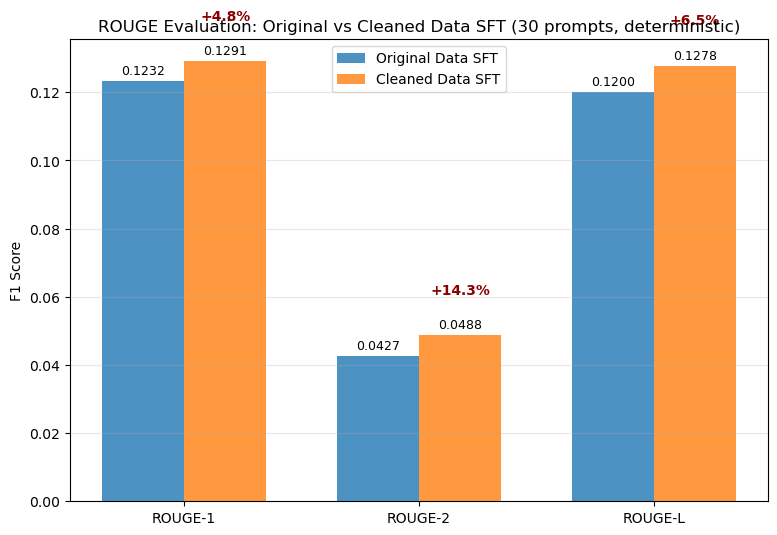

In [54]:
# ============================================
# [Cell 64] 그래프 4: ROUGE 정량 평가 비교 (원본 vs 정제 데이터 SFT)
# 프로젝트의 핵심 결론을 보여주는 그래프
# 30개 동일 prompt, 동일 생성 설정(do_sample=False)에서
# 세 지표 모두 정제 데이터 모델이 우세함을 시각화
# ============================================

import numpy as np

metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
original_scores = [0.1232, 0.0427, 0.1200]
cleaned_scores = [0.1291, 0.0488, 0.1278]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 6))
bars1 = plt.bar(x - width/2, original_scores, width, label='Original Data SFT', color='tab:blue', alpha=0.8)
bars2 = plt.bar(x + width/2, cleaned_scores, width, label='Cleaned Data SFT', color='tab:orange', alpha=0.8)

# 막대 위에 점수 표시
for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{bar.get_height():.4f}', ha='center', fontsize=9)

# 향상률 표시
improvements = ['+4.8%', '+14.3%', '+6.5%']
for i, imp in enumerate(improvements):
    plt.text(x[i] + width/2, cleaned_scores[i] + 0.012, imp,
             ha='center', fontweight='bold', color='darkred')

plt.xticks(x, metrics)
plt.ylabel('F1 Score')
plt.title('ROUGE Evaluation: Original vs Cleaned Data SFT (30 prompts, deterministic)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('graph_4_rouge_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 프로젝트 최종 결론: KoChatGPT 업그레이드

## 1. 수행 내용 요약
KoGPT-2(125M)를 foundation model로 RLHF 전체 파이프라인(SFT → RM → PPO)을
구현하고, **기존 데이터셋 추가 정제** 전략으로 모델 성능을 개선했다.
개선 효과는 에폭 수(3)·하이퍼파라미터·평가 prompt(30개, seed 고정)·
디코딩 설정(do_sample=False)을 모두 통제한 조건에서 검증했다.

## 2. 최종 성능 결과

### 정량 평가 (ROUGE, 핵심 결과)
| 지표 | 원본 데이터 SFT | 정제 데이터 SFT | 향상률 |
|---|---|---|---|
| ROUGE-1 F1 | 0.1232 | **0.1291** | +4.8% |
| ROUGE-2 F1 | 0.0427 | **0.0488** | **+14.3%** |
| ROUGE-L F1 | 0.1200 | **0.1278** | +6.5% |

→ 빈 prompt 제거(3건) + 답변 앞 작은따옴표 제거(11,482건, 95.7%)라는
간단한 정제만으로 세 지표 모두 일관된 향상. 특히 ROUGE-2의 큰 향상은
어구 수준의 유창성이 개선되었음을 의미.

### 정성 평가 (모델 단계별 변화)
| 모델 | 성능 특징 |
|---|---|
| 기존 KoGPT-2 | 질문에 응답하지 못하고 소설식 이어쓰기만 수행 (greedy 시 무한 반복) |
| SFT (원본) | 질문에 응답하는 능력 획득. 단, 모든 답변이 '로 시작 + 환각 존재 |
| SFT (정제) | **따옴표 노이즈 100% 제거**, 응답 형식 개선 |
| RLHF (PPO) | 답변 초반은 유지되나 후반부 외국어 혼입·문장 붕괴 (아래 원인 분석) |

## 3. 주요 발견 및 분석

1. **"낮은 loss ≠ 좋은 성능"**: 정제 데이터의 학습 loss는 근소하게 높았으나
   (따옴표라는 '공짜 정답 토큰'이 사라진 탓) 실제 생성 품질은 ROUGE에서 우세.
   학습 지표와 생성 품질을 구분해서 평가해야 함을 실증.

2. **RM의 길이 편향과 reward hacking**: RM 검증에서 비방성 짧은 문장(-1.7)이
   정상 정의문(-1.8)보다 높은 점수를 받는 역전 발견. RM이 내용보다 "길이·상세함"을
   품질 신호로 학습한 결과, PPO에서 actor가 보상을 노리고 무의미하게 긴 문장을
   생성하는 정책 붕괴로 이어짐. → **RLHF의 성패는 RM 품질에 결정적으로 의존**함을 확인.

3. **작은 foundation model의 한계**: 125M 모델은 emergent abilities를 기대하기
   어려우며, KL 페널티에도 불구하고 PPO 과정에서 정책이 쉽게 불안정해짐.

## 4. 향후 개선 방향
- RM 학습 데이터 확대 (현재 20,440쌍 중 1,000쌍만 사용 → 전체 활용)
- 짧지만 좋은 답변 vs 짧고 나쁜 답변 쌍 보강으로 RM의 길이 편향 완화
- foundation model 교체 (skt/ko-gpt-trinity-1.2B) + LoRA로 메모리 문제 해결
- PPO 에피소드 수 증가 및 KL 페널티 계수 튜닝
